In [12]:
#!/usr/bin/env python
"""
C2H4 (12e,14o)/cc-pVDZ TWIST scan — STATE-RESOLVED AMPLITUDE + NUMBA JIT VERSION

Closed-shell C2H4 with C=C double bond, ground + lowest two singlet/triplet states.
NELEC = (6, 6): alpha has C(NORB,6) strings.

States: S0, T1, T2, S1, S2 (3 singlets + 2 triplets)

Geometry: dihedral twist about C-C bond
  - d(C-C) = 1.34 A (fixed)
  - d(C-H) = 1.08 A (fixed)
  - angle(HCC) = 121.5 deg (fixed)
  - theta = 0..180 deg (scan variable)
    theta = 0: planar D2h
    theta = 90: twisted D2d (biradicaloid)
    theta = 180: planar D2h (mirror image of theta=0)

Output JSON entry uses key "R" with value = theta (degrees), matching the
N2 script structure exactly so downstream figure scripts work identically.

wf_amps[state_label] = {ref_a/b, ext_a/b, cipsi_a/b}
All on full space (0-padded). For closed-shell C2H4, alpha and beta are
mirror-equivalent but stored separately for consistency with the N2 format.
"""

# %% Cell 1: Imports
import os, time, json, math, numpy as np

from pyscf import gto, scf, cc, mcscf, ao2mo, fci, lib
from pyscf.fci import selected_ci, cistring
from qiskit.circuit import QuantumCircuit
from qiskit_addon_sqd.fermion import (
    enlarge_batch_from_transitions,
    bitstring_matrix_to_ci_strs,
    recover_configurations,
    subsample,
    postselect_by_hamming_right_and_left,
    solve_fermion,
)
import ffsim
import warnings
warnings.filterwarnings("ignore")

N_THREADS = int(os.environ.get("OMP_NUM_THREADS", 24))
lib.num_threads(N_THREADS)
print(f"PySCF threads: {N_THREADS}")

# %% Cell 2: System & algorithm parameters

NORB = 14
NELEC = (6, 6)       # closed-shell singlet GS, 12 active electrons
NCORE = 2            # 2x C 1s frozen

TARGET_STATES = ["S0", "T1", "T2", "S1", "S2"]
MAX_SINGLET = 3      # S0, S1, S2
MAX_TRIPLET = 2      # T1, T2

# SQD pipeline
SAMPLE_MODE = "lucj"   # "casci" or "lucj"
N_SHOTS = 100000
N_SEEDS = 1
NOISE_LEVEL = 0.1
S_CORE_ITER = 5
N_BATCHES = 10
SAMPLES_PER_BATCH = 500
MERGE_TOP_K = 1
NROOTS_FINAL = 10    # general FCI nroots

# CIPSI
CIPSI_ACUT = 3e-3
CIPSI_BROAD_EPS = 5e-4
CIPSI_EN_EPS = 1e-6
CIPSI_MAX_ITER = 10
CIPSI_EXT_ROOTS = 10
CIPSI_BROAD_MULT = 10
CIPSI_BROAD_FRAC = 0.01
NROOTS_GROW = 10
GROW_CONV_TOL = 1e-4
GROW_MAX_CYCLE = 30


# %% Cell 3: Core functions

def safe_array(x):
    return np.nan_to_num(np.asarray(x, float))

def det_strings(norb, nelec):
    na, nb = nelec
    return (np.array(cistring.make_strings(range(norb), na), np.int64),
            np.array(cistring.make_strings(range(norb), nb), np.int64))

def reverse_bits(s, norb):
    """Reverse bit order of integer s within norb bits.
    bitstring_matrix_to_ci_strs uses reversed bit convention vs PySCF cistring."""
    result = 0
    for i in range(norb):
        if (s >> i) & 1:
            result |= (1 << (norb - 1 - i))
    return result

def fix_ci_strs(strs, norb):
    return np.array(sorted(set(reverse_bits(int(s), norb) for s in strs)), dtype=np.int64)

def classify_spin(s2):
    if abs(s2) < 0.4: return "singlet"
    if abs(s2 - 2.0) < 0.5: return "triplet"
    return "other"

def kernel_safe(myci, h1, eri, norb, nelec, ci_strs, nroots, loose=False):
    try:
        if loose:
            myci.conv_tol = GROW_CONV_TOL; myci.max_cycle = GROW_MAX_CYCLE
        else:
            myci.conv_tol = 1e-10; myci.max_cycle = 200
        e, c = selected_ci.kernel_fixed_space(
            myci, h1, eri, norb, nelec, ci_strs=ci_strs, nroots=nroots)
        if np.isscalar(e): return [float(e)], [c]
        return [float(x) for x in e], list(c)
    except:
        return [], []

def get_alpha_coeffs(c_full, strsa, basis, ci_strs):
    c = np.asarray(c_full)
    coeffs = np.zeros(len(basis))
    if c.ndim == 2:
        sm = {int(s): i for i, s in enumerate(ci_strs[0])}
        for bi, bs in enumerate(basis):
            ia = sm.get(int(bs))
            if ia is not None and ia < c.shape[0]:
                coeffs[bi] = np.max(np.abs(c[ia, :]))
    return coeffs

def get_beta_coeffs(c_full, strsb, basis_b, ci_strs):
    c = np.asarray(c_full)
    coeffs = np.zeros(len(basis_b))
    if c.ndim == 2:
        sm = {int(s): i for i, s in enumerate(ci_strs[1])}
        for bi, bs in enumerate(basis_b):
            ib = sm.get(int(bs))
            if ib is not None and ib < c.shape[1]:
                coeffs[bi] = np.max(np.abs(c[:, ib]))
    return coeffs

def compute_state_marginals(ci_vec, sub_a, sub_b, full_a_map, full_b_map,
                             n_alpha_full, n_beta_full):
    """Compute alpha/beta marginals on full space (0-padded outside subspace)."""
    c = np.asarray(ci_vec, float)
    if c.ndim != 2: return None, None
    pa_sub = np.sum(c**2, axis=1)
    pb_sub = np.sum(c**2, axis=0)
    pa_full = np.zeros(n_alpha_full)
    pb_full = np.zeros(n_beta_full)
    for i_sub in range(min(len(sub_a), len(pa_sub))):
        i_full = full_a_map.get(int(sub_a[i_sub]))
        if i_full is not None: pa_full[i_full] = pa_sub[i_sub]
    for i_sub in range(min(len(sub_b), len(pb_sub))):
        i_full = full_b_map.get(int(sub_b[i_sub]))
        if i_full is not None: pb_full[i_full] = pb_sub[i_sub]
    return pa_full, pb_full

# === Numba JIT acceleration ===
try:
    from numba import njit
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False

if HAS_NUMBA:
    @njit(cache=True)
    def _in_sorted(val, arr):
        """Binary search in sorted int64 array."""
        lo, hi = 0, len(arr) - 1
        while lo <= hi:
            mid = (lo + hi) // 2
            if arr[mid] == val: return True
            elif arr[mid] < val: lo = mid + 1
            else: hi = mid - 1
        return False

    @njit(cache=True)
    def _compute_diag_jit(s, norb, h1, eri):
        """JIT diagonal H element."""
        occ = np.empty(norb, dtype=np.int64); nocc = 0
        for i in range(norb):
            if (s >> i) & 1:
                occ[nocc] = i; nocc += 1
        e = 0.0
        for ii in range(nocc):
            i = occ[ii]; e += h1[i, i]
        for ii in range(nocc):
            i = occ[ii]
            for jj in range(ii+1, nocc):
                j = occ[jj]; e += eri[i, i, j, j] - eri[i, j, j, i]
        return e

    @njit(cache=True)
    def _en_couplings_one_config(s, ck, norb, h1, eri, bs_sorted):
        """JIT: compute S/D couplings from one source config.
        Returns (candidate_configs, coupling_values) arrays."""
        occ = np.empty(norb, dtype=np.int64); nocc = 0
        vir = np.empty(norb, dtype=np.int64); nvir = 0
        for i in range(norb):
            if (s >> i) & 1: occ[nocc] = i; nocc += 1
            else: vir[nvir] = i; nvir += 1

        max_n = nocc * nvir + (nocc * (nocc-1) // 2) * (nvir * (nvir-1) // 2)
        cands = np.empty(max_n, dtype=np.int64)
        coups = np.empty(max_n, dtype=np.float64)
        n = 0

        # Singles
        for ii in range(nocc):
            i = occ[ii]
            for aa in range(nvir):
                a = vir[aa]
                ns = s ^ (1 << i) ^ (1 << a)
                if _in_sorted(ns, bs_sorted): continue
                v = h1[a, i]
                for jj in range(nocc):
                    j_occ = occ[jj]
                    v += eri[a, j_occ, i, j_occ] - eri[a, j_occ, j_occ, i]
                cands[n] = ns; coups[n] = v * ck; n += 1

        # Doubles
        for ii in range(nocc):
            i = occ[ii]
            for jj in range(ii+1, nocc):
                j = occ[jj]
                for aa in range(nvir):
                    a = vir[aa]
                    for bb in range(aa+1, nvir):
                        b = vir[bb]
                        ns = s ^ (1 << i) ^ (1 << j) ^ (1 << a) ^ (1 << b)
                        if _in_sorted(ns, bs_sorted): continue
                        v = eri[a, i, b, j] - eri[a, j, b, i]
                        cands[n] = ns; coups[n] = v * ck; n += 1
        return cands[:n], coups[:n]

    @njit(cache=True)
    def _broad_one_config(s, norb, eri, eps, bs_sorted):
        """JIT: broad mode S/D from one config. Singles always added, doubles eps-filtered."""
        occ = np.empty(norb, dtype=np.int64); nocc = 0
        vir = np.empty(norb, dtype=np.int64); nvir = 0
        for i in range(norb):
            if (s >> i) & 1: occ[nocc] = i; nocc += 1
            else: vir[nvir] = i; nvir += 1

        max_n = nocc * nvir + (nocc * (nocc-1) // 2) * (nvir * (nvir-1) // 2)
        cands = np.empty(max_n, dtype=np.int64)
        n = 0

        for ii in range(nocc):
            i = occ[ii]
            for aa in range(nvir):
                a = vir[aa]
                ns = s ^ (1 << i) ^ (1 << a)
                if not _in_sorted(ns, bs_sorted):
                    cands[n] = ns; n += 1

        for ii in range(nocc):
            i = occ[ii]
            for jj in range(ii+1, nocc):
                j = occ[jj]
                for aa in range(nvir):
                    a = vir[aa]
                    for bb in range(aa+1, nvir):
                        b = vir[bb]
                        ns = s ^ (1 << i) ^ (1 << j) ^ (1 << a) ^ (1 << b)
                        if _in_sorted(ns, bs_sorted): continue
                        if eps > 0:
                            v = abs(eri[a, i, b, j] - eri[a, j, b, i])
                            if v < eps: continue
                        cands[n] = ns; n += 1
        return cands[:n]

    @njit(cache=True)
    def _pairwise_one_config(s, ck, norb, h1, eri, eps, bs_sorted):
        """JIT: standard pair-wise |H_ij * c_j| > eps from one config."""
        occ = np.empty(norb, dtype=np.int64); nocc = 0
        vir = np.empty(norb, dtype=np.int64); nvir = 0
        for i in range(norb):
            if (s >> i) & 1: occ[nocc] = i; nocc += 1
            else: vir[nvir] = i; nvir += 1

        max_n = nocc * nvir + (nocc * (nocc-1) // 2) * (nvir * (nvir-1) // 2)
        cands = np.empty(max_n, dtype=np.int64)
        n = 0

        for ii in range(nocc):
            i = occ[ii]
            for aa in range(nvir):
                a = vir[aa]
                ns = s ^ (1 << i) ^ (1 << a)
                if _in_sorted(ns, bs_sorted): continue
                v = h1[a, i]
                for jj in range(nocc):
                    j = occ[jj]
                    v += eri[a, j, i, j] - eri[a, j, j, i]
                if abs(v) * ck < eps: continue
                cands[n] = ns; n += 1

        for ii in range(nocc):
            i = occ[ii]
            for jj in range(ii+1, nocc):
                j = occ[jj]
                for aa in range(nvir):
                    a = vir[aa]
                    for bb in range(aa+1, nvir):
                        b = vir[bb]
                        ns = s ^ (1 << i) ^ (1 << j) ^ (1 << a) ^ (1 << b)
                        if _in_sorted(ns, bs_sorted): continue
                        v = abs(eri[a, i, b, j] - eri[a, j, b, i])
                        if v * ck < eps: continue
                        cands[n] = ns; n += 1
        return cands[:n]

    print(f"Numba JIT: enabled (4 functions compiled on first call)")

else:
    print("Numba: not available, using pure Python (slower)")


def _compute_diag(s, norb, h1, eri):
    if HAS_NUMBA:
        return _compute_diag_jit(s, norb, h1, eri)
    occ = [i for i in range(norb) if (s >> i) & 1]
    e = 0.0
    for i in occ:
        e += h1[i, i]
    for ii, i in enumerate(occ):
        for j in occ[ii+1:]:
            e += eri[i, i, j, j] - eri[i, j, j, i]
    return e


def cipsi_extend(basis, ci_coeffs, norb, ne, acut, maxd, h1, eri, eps,
              use_coeffs=True, broad_frac=0.01, en_mode=False, e0=0.0):
    """Heat-bath extension with Epstein-Nesbet perturbative selection.

    Modes:
      use_coeffs=False: Broad mode - singles always added, doubles eps-filtered
      use_coeffs=True, en_mode=False: Standard pair-wise |H_ij * c_j| > eps
      use_coeffs=True, en_mode=True:  EN mode - accumulate coupling from all
          source configs, then filter by dE = |sum H_Ij c_j|^2 / |E0 - H_II| > eps
    """
    bs = set(int(x) for x in basis)
    bs_sorted = np.array(sorted(bs), dtype=np.int64)  # for JIT binary search

    if use_coeffs:
        if isinstance(ci_coeffs, list):
            imp_ref = np.abs(ci_coeffs[0]) >= acut
            if imp_ref.sum() < 5:
                imp_ref[np.argsort(-np.abs(ci_coeffs[0]))[:5]] = True
        else:
            imp = np.abs(ci_coeffs) >= acut
            if imp.sum() < 5:
                imp[np.argsort(-np.abs(ci_coeffs))[:5]] = True
    else:
        cmax = np.max(np.abs(ci_coeffs)) if len(ci_coeffs) > 0 else 0
        threshold = cmax * broad_frac
        imp = np.abs(ci_coeffs) >= threshold
        if imp.sum() < 5:
            imp[np.argsort(-np.abs(ci_coeffs))[:min(5, len(basis))]] = True

    # === BROAD MODE ===
    if not use_coeffs:
        imp_idx = np.where(imp)[0]
        cands = set()
        if HAS_NUMBA:
            for k in imp_idx:
                new_configs = _broad_one_config(int(basis[k]), norb, eri, eps, bs_sorted)
                for ci in range(len(new_configs)):
                    cands.add(int(new_configs[ci]))
        else:
            for k in imp_idx:
                s = int(basis[k])
                occ = [i for i in range(norb) if (s >> i) & 1]
                vir = [i for i in range(norb) if not ((s >> i) & 1)]
                for i in occ:
                    for a in vir:
                        ns = s ^ (1 << i) ^ (1 << a)
                        if ns not in bs: cands.add(ns)
                for ii, i in enumerate(occ):
                    for j in occ[ii+1:]:
                        for aa, a in enumerate(vir):
                            for b in vir[aa+1:]:
                                ns = s ^ (1<<i) ^ (1<<j) ^ (1<<a) ^ (1<<b)
                                if ns in bs: continue
                                if eps > 0:
                                    v = abs(eri[a,i,b,j] - eri[a,j,b,i])
                                    if v < eps: continue
                                cands.add(ns)
        r = np.array(sorted(bs | cands), np.int64)
        return r[:maxd] if maxd and len(r) > maxd else r

    # === EN MODE ===
    if en_mode:
        if isinstance(e0, (list, np.ndarray)):
            e0_list = list(e0); coeffs_list = list(ci_coeffs)
        else:
            e0_list = [e0]; coeffs_list = [ci_coeffs]

        all_couplings = []
        for ri, (e0_r, coeffs_r) in enumerate(zip(e0_list, coeffs_list)):
            imp_r = np.abs(coeffs_r) >= acut
            if imp_r.sum() < 5:
                imp_r[np.argsort(-np.abs(coeffs_r))[:5]] = True
            imp_idx_r = np.where(imp_r)[0]

            coupling = {}
            if HAS_NUMBA:
                for k in imp_idx_r:
                    s = int(basis[k]); ck = float(coeffs_r[k])
                    new_c, new_v = _en_couplings_one_config(s, ck, norb, h1, eri, bs_sorted)
                    for ci in range(len(new_c)):
                        ns = int(new_c[ci])
                        coupling[ns] = coupling.get(ns, 0.0) + new_v[ci]
            else:
                from collections import defaultdict
                coupling = defaultdict(float)
                for k in imp_idx_r:
                    s = int(basis[k]); ck = float(coeffs_r[k])
                    occ = [i for i in range(norb) if (s >> i) & 1]
                    vir = [i for i in range(norb) if not ((s >> i) & 1)]
                    for i in occ:
                        for a in vir:
                            ns = s ^ (1 << i) ^ (1 << a)
                            if ns in bs: continue
                            v = h1[a, i]
                            for j_occ in occ:
                                v += eri[a, j_occ, i, j_occ] - eri[a, j_occ, j_occ, i]
                            coupling[ns] += v * ck
                    for ii, i in enumerate(occ):
                        for j in occ[ii+1:]:
                            for aa, a in enumerate(vir):
                                for b in vir[aa+1:]:
                                    ns = s ^ (1<<i) ^ (1<<j) ^ (1<<a) ^ (1<<b)
                                    if ns in bs: continue
                                    v = eri[a,i,b,j] - eri[a,j,b,i]
                                    coupling[ns] += v * ck
            all_couplings.append((coupling, e0_r))

        all_candidates = set()
        for coupling, _ in all_couplings:
            all_candidates |= set(coupling.keys())
        cands = set()
        for ns in all_candidates:
            h_ii = _compute_diag(ns, norb, h1, eri)
            for coupling, e0_r in all_couplings:
                coup = coupling.get(ns, 0.0)
                if abs(coup) < 1e-15: continue
                denom = abs(e0_r - h_ii)
                if denom < 1e-12: denom = 1e-12
                delta_e = coup * coup / denom
                if delta_e > eps:
                    cands.add(ns); break
        r = np.array(sorted(bs | cands), np.int64)
        return r[:maxd] if maxd and len(r) > maxd else r

    # === STANDARD PAIR-WISE MODE ===
    imp_idx = np.where(imp)[0]
    cands = set()
    if HAS_NUMBA:
        for k in imp_idx:
            new_configs = _pairwise_one_config(int(basis[k]), abs(float(ci_coeffs[k])),
                                                norb, h1, eri, eps, bs_sorted)
            for ci in range(len(new_configs)):
                cands.add(int(new_configs[ci]))
    else:
        for k in imp_idx:
            s = int(basis[k]); ck = abs(ci_coeffs[k])
            occ = [i for i in range(norb) if (s >> i) & 1]
            vir = [i for i in range(norb) if not ((s >> i) & 1)]
            for i in occ:
                for a in vir:
                    ns = s ^ (1 << i) ^ (1 << a)
                    if ns in bs: continue
                    v = h1[a, i]
                    for j in occ:
                        v += eri[a, j, i, j] - eri[a, j, j, i]
                if abs(v) * ck < eps: continue
                cands.add(ns)
            for ii, i in enumerate(occ):
                for j in occ[ii+1:]:
                    for aa, a in enumerate(vir):
                        for b in vir[aa+1:]:
                            ns = s ^ (1<<i) ^ (1<<j) ^ (1<<a) ^ (1<<b)
                            if ns in bs: continue
                            v = abs(eri[a,i,b,j] - eri[a,j,b,i])
                            if v * ck < eps: continue
                            cands.add(ns)
    r = np.array(sorted(bs | cands), np.int64)
    return r[:maxd] if maxd and len(r) > maxd else r


def build_sd_transitions(norb, nelec):
    """Build all single+double excitation operators (closed-shell)."""
    na, nb = nelec; ops = []
    # Alpha singles
    for i in range(na):
        for a in range(na, norb):
            op = np.full(2*norb, 'I', dtype='U1'); op[norb+a]='+'; op[norb+i]='-'; ops.append(op)
    # Alpha doubles
    for i in range(na):
        for j in range(i+1, na):
            for a in range(na, norb):
                for b in range(a+1, norb):
                    op = np.full(2*norb, 'I', dtype='U1'); op[norb+a]='+'; op[norb+b]='+'; op[norb+i]='-'; op[norb+j]='-'; ops.append(op)
    # Beta singles
    for i in range(nb):
        for a in range(nb, norb):
            op = np.full(2*norb, 'I', dtype='U1'); op[a]='+'; op[i]='-'; ops.append(op)
    # Beta doubles
    for i in range(nb):
        for j in range(i+1, nb):
            for a in range(nb, norb):
                for b in range(a+1, norb):
                    op = np.full(2*norb, 'I', dtype='U1'); op[a]='+'; op[b]='+'; op[i]='-'; op[j]='-'; ops.append(op)
    return np.array(ops)


def sample_bsm(norb, nelec, n_shots, noise_level=0.1, seed=42,
               mode="lucj", ci_vec=None, t1=None, t2=None):
    """Simulate QPU sampling -> bitstring_matrix.

    mode="casci": Sample from CASCI GS wavefunction |c|^2 (best seed quality)
    mode="lucj":  Sample from LUCJ circuit with CCSD amplitudes (default)

    Both add depolarizing noise to simulate QPU decoherence.
    Convention: left=beta (0..norb-1), right=alpha (norb..2*norb-1)."""
    rng = np.random.default_rng(seed)
    na, nb = nelec
    strsa, strsb = det_strings(norb, nelec)
    n_b = len(strsb)

    if mode == "casci" and ci_vec is not None:
        cf = np.asarray(ci_vec, float)
        probs_exact = (cf**2).ravel(); probs_exact /= probs_exact.sum()
    elif mode == "lucj" and t1 is not None and t2 is not None:
        t2a, t1a = safe_array(t2), safe_array(t1)
        probs_merged = None; n_merged = 0
        for ts in [0.5, 1.0, 1.5, 2.0]:
            try:
                qc = QuantumCircuit(2*norb)
                qc.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), list(range(2*norb)))
                qc.barrier()
                ucj = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
                    t2=t2a*ts, t1=t1a*ts, n_reps=8)
                qc.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj), list(range(2*norb)))
                vec = ffsim.qiskit.final_state_vector(qc, norb=norb, nelec=nelec)
                p = np.abs(np.asarray(vec, np.complex128))**2
                if probs_merged is None: probs_merged = p.copy()
                else: probs_merged += p
                n_merged += 1
            except Exception:
                pass
        if probs_merged is not None and n_merged > 0:
            probs_exact = probs_merged / n_merged
        else:
            probs_exact = np.zeros(len(strsa)*n_b); probs_exact[0] = 1.0
    else:
        probs_exact = np.zeros(len(strsa)*n_b); probs_exact[0] = 1.0

    probs_noisy = (1-noise_level)*probs_exact + noise_level/len(probs_exact)
    probs_noisy /= probs_noisy.sum()

    indices = rng.choice(len(probs_noisy), size=n_shots, p=probs_noisy)
    bsm = np.zeros((n_shots, 2*norb), dtype=bool); shot_probs = np.zeros(n_shots)
    for k, idx in enumerate(indices):
        ia, ib = idx//n_b, idx%n_b; a, b = int(strsa[ia]), int(strsb[ib])
        for i in range(norb):
            if (b >> i) & 1: bsm[k, i] = True
            if (a >> i) & 1: bsm[k, norb+i] = True
        shot_probs[k] = probs_noisy[idx]
    shot_probs /= shot_probs.sum()
    return bsm, shot_probs


def label_states_fci(solver, e_list, c_list, norb, nelec, e_core):
    """Label FCI roots as S0..S{MAX_SINGLET-1}, T1..T{MAX_TRIPLET}.
    Returns (energy_dict, s2_dict, idx_map)."""
    labeled, s2_dict, idx_map = {}, {}, {}
    s_cnt, t_cnt = 0, 0
    for k in range(len(e_list)):
        s2, _ = solver.spin_square(c_list[k], norb, nelec)
        s2 = float(s2); tag = classify_spin(s2)
        if tag == "singlet" and s_cnt < MAX_SINGLET:
            lb = f"S{s_cnt}"; s_cnt += 1
        elif tag == "triplet" and t_cnt < MAX_TRIPLET:
            lb = f"T{t_cnt+1}"; t_cnt += 1
        else: continue
        labeled[lb] = float(e_core + e_list[k]); s2_dict[lb] = s2; idx_map[lb] = k
        if s_cnt >= MAX_SINGLET and t_cnt >= MAX_TRIPLET: break
    return labeled, s2_dict, idx_map


def label_states_sci(myci, e_list, c_list, norb, nelec, e_core):
    """Label selected_ci roots. Returns (energy_dict, s2_dict, idx_map)."""
    labeled, s2_dict, idx_map = {}, {}, {}
    s_cnt, t_cnt = 0, 0
    for k in range(len(e_list)):
        try: s2 = float(selected_ci.spin_square(c_list[k], norb, nelec)[0])
        except: s2 = -1.0
        tag = classify_spin(s2)
        if tag == "singlet" and s_cnt < MAX_SINGLET:
            lb = f"S{s_cnt}"; s_cnt += 1
        elif tag == "triplet" and t_cnt < MAX_TRIPLET:
            lb = f"T{t_cnt+1}"; t_cnt += 1
        else: continue
        labeled[lb] = float(e_core + e_list[k]); s2_dict[lb] = s2; idx_map[lb] = k
        if s_cnt >= MAX_SINGLET and t_cnt >= MAX_TRIPLET: break
    return labeled, s2_dict, idx_map


# %% Cell 4: Build C2H4 molecule with twist angle theta

# Standard ethylene parameters (fixed across the scan)
D_CC = 1.34         # C-C bond length (A)
D_CH = 1.08         # C-H bond length (A)
ANGLE_HCC = 121.5   # H-C-C angle (degrees), sp2 standard

def build_c2h4(theta):
    """Build C2H4 with twist angle theta (degrees) about the C-C bond.

    Geometry construction:
      - C1 at (0, 0, -D_CC/2), C2 at (0, 0, +D_CC/2)
      - C1's two H atoms in the xz plane (theta-independent)
      - C2's two H atoms rotated by `theta` around the z-axis

    At theta = 0 deg : planar D2h (HOMO-LUMO gap large, single-reference)
    At theta = 90 deg: twisted D2d (biradicaloid, multi-reference)
    At theta = 180 deg: planar D2h (mirror of theta=0, equivalent)
    """
    theta_rad = math.radians(ANGLE_HCC)
    sin_t = math.sin(theta_rad)
    cos_t = math.cos(theta_rad)  # negative for ANGLE_HCC > 90

    # C atoms along z
    z1 = -D_CC / 2.0
    z2 = +D_CC / 2.0

    # C1 hydrogens (planar, xz plane) — H below C1 (negative z component from C1)
    h1_radial = D_CH * sin_t           # radial distance in xy-plane
    h1_z = z1 + D_CH * cos_t           # cos(121.5deg) < 0 -> H1 below C1
    h1a = (+h1_radial, 0.0, h1_z)
    h1b = (-h1_radial, 0.0, h1_z)

    # C2 hydrogens (rotated by theta around z-axis) — H above C2 (positive z from C2)
    h2_radial = D_CH * sin_t
    h2_z = z2 - D_CH * cos_t           # H2 above C2 (mirror of C1 case)
    phi = math.radians(theta)
    cos_p, sin_p = math.cos(phi), math.sin(phi)
    h2a = (+h2_radial * cos_p, +h2_radial * sin_p, h2_z)
    h2b = (-h2_radial * cos_p, -h2_radial * sin_p, h2_z)

    atom_str = (
        f"C 0.0 0.0 {z1};"
        f"C 0.0 0.0 {z2};"
        f"H {h1a[0]} {h1a[1]} {h1a[2]};"
        f"H {h1b[0]} {h1b[1]} {h1b[2]};"
        f"H {h2a[0]} {h2a[1]} {h2a[2]};"
        f"H {h2b[0]} {h2b[1]} {h2b[2]}"
    )

    mol = gto.M(atom=atom_str, basis="cc-pvdz", unit="Angstrom",
                verbose=0, max_memory=8000)
    mf = scf.RHF(mol).run(conv_tol=1e-12)
    mc = mcscf.CASCI(mf, ncas=NORB, nelecas=NELEC)
    mc.ncore = NCORE; mc.mo_coeff = mf.mo_coeff
    h1, e_core = mc.get_h1eff()
    eri = ao2mo.restore(1, mc.get_h2eff(), NORB)

    nocc, nvir = 6, NORB - 6
    try:
        mycc = cc.CCSD(mf, frozen=NCORE)
        mycc.conv_tol = 1e-10; mycc.max_cycle = 100; mycc.kernel()
        t1 = safe_array(mycc.t1[:nocc, :nvir])
        t2 = safe_array(mycc.t2[:nocc, :nocc, :nvir, :nvir])
    except:
        rng = np.random.default_rng(42)
        t1 = rng.normal(0, 0.03, (nocc, nvir))
        t2 = rng.normal(0, 0.01, (nocc, nocc, nvir, nvir))
        t2 = t2 - t2.transpose(1, 0, 2, 3)

    return h1, eri, float(e_core), t1, t2, mf


# %% Cell 5: Compute single geometry

def compute_point(theta):
    """Compute one geometry. theta in degrees.
    Stores theta as 'R' in the output entry to match N2 JSON schema."""
    print(f"\n  theta = {theta:.0f} deg", end="", flush=True)
    t0_all = time.time()
    na, nb = NELEC

    h1, eri, e_core, t1, t2, mf = build_c2h4(theta)
    strsa, strsb = det_strings(NORB, NELEC)
    n_alpha_full, n_beta_full = len(strsa), len(strsb)
    full_a_map = {int(s): i for i, s in enumerate(strsa)}
    full_b_map = {int(s): i for i, s in enumerate(strsb)}

    # --- Reference (general FCI + S^2 label) ---
    t0 = time.time()
    solver = fci.direct_spin1.FCI()
    solver.conv_tol = 1e-10; solver.max_memory = 8000; solver.max_cycle = 200
    e_fci, c_fci = solver.kernel(h1, eri, NORB, NELEC, nroots=NROOTS_FINAL)
    if np.isscalar(e_fci): e_fci, c_fci = [float(e_fci)], [c_fci]
    fci_labeled, fci_s2, fci_idx_map = label_states_fci(
        solver, e_fci, c_fci, NORB, NELEC, e_core)
    dt_fci = time.time() - t0

    # === SQD Pipeline ===

    # HF bitstring for tracking
    hf_bsm = np.zeros(2*NORB, dtype=bool)
    for i in range(na): hf_bsm[NORB+i] = True
    for i in range(nb): hf_bsm[i] = True
    def count_hf(bsm):
        return sum(1 for row in bsm if np.array_equal(row, hf_bsm))

    t0 = time.time()
    bsm_parts, probs_parts = [], []
    for s_idx in range(N_SEEDS):
        bsm_s, probs_s = sample_bsm(
            NORB, NELEC, N_SHOTS, NOISE_LEVEL, seed=42+s_idx*1000,
            mode=SAMPLE_MODE, ci_vec=c_fci[fci_idx_map.get("S0", 0)] if "S0" in fci_idx_map else None,
            t1=t1, t2=t2)
        bsm_parts.append(bsm_s); probs_parts.append(probs_s)
    bsm_raw = np.vstack(bsm_parts)
    probs_raw = np.concatenate(probs_parts); probs_raw /= probs_raw.sum()
    n_hf_raw = count_hf(bsm_raw)

    bsm_ps, probs_ps = postselect_by_hamming_right_and_left(
        bsm_raw, probs_raw, hamming_right=na, hamming_left=nb)
    n_hf_ps = count_hf(bsm_ps)

    for it in range(S_CORE_ITER):
        energy_sqd, sci_state, avg_occs, spin_sq = solve_fermion(
            bsm_ps, hcore=h1, eri=eri)
        bsm_ps, probs_ps = recover_configurations(
            bsm_ps, probs_ps, avg_occs, na, nb, rand_seed=42+it)
    n_hf_score = count_hf(bsm_ps)

    spb = min(SAMPLES_PER_BATCH, len(bsm_ps))
    batches = subsample(bsm_ps, probs_ps, spb, N_BATCHES, rand_seed=42)
    batch_energies = []
    hf_in_batch = []
    for i, batch in enumerate(batches):
        e_b, _, _, _ = solve_fermion(batch, hcore=h1, eri=eri)
        batch_energies.append((e_b, i)); hf_in_batch.append(count_hf(batch))
    batch_energies.sort()
    top_k_indices = [idx for _, idx in batch_energies[:MERGE_TOP_K]]
    hf_in_topk = sum(hf_in_batch[idx] for idx in top_k_indices)

    merged_rows = []
    for _, idx in batch_energies[:MERGE_TOP_K]:
        merged_rows.append(batches[idx])
    merged_batch = np.vstack(merged_rows)
    _, unique_idx = np.unique(merged_batch, axis=0, return_index=True)
    merged_batch = merged_batch[np.sort(unique_idx)]
    n_hf_merged = count_hf(merged_batch)

    print(f"\n    [HF-TRACK] raw:{n_hf_raw}/{len(bsm_raw)} -> "
          f"postsel:{n_hf_ps}/{len(bsm_ps)} -> "
          f"score:{n_hf_score}/{len(bsm_ps)} -> "
          f"topK({top_k_indices}):{hf_in_topk} -> "
          f"merged:{n_hf_merged}/{len(merged_batch)}", flush=True)

    sqd_a, sqd_b = bitstring_matrix_to_ci_strs(merged_batch, open_shell=False)
    sqd_a = fix_ci_strs(sqd_a, NORB); sqd_b = fix_ci_strs(sqd_b, NORB)
    dt_sqd = time.time() - t0

    # === Ext-SQD ===
    t0 = time.time()
    ops = build_sd_transitions(NORB, NELEC)
    ext_bsm = enlarge_batch_from_transitions(merged_batch, ops)
    ext_a, ext_b = bitstring_matrix_to_ci_strs(ext_bsm, open_shell=False)
    ext_a = fix_ci_strs(ext_a, NORB); ext_b = fix_ci_strs(ext_b, NORB)

    myci = selected_ci.SelectedCI()
    myci.conv_tol = 1e-10; myci.max_cycle = 200; myci.max_memory = 8000
    ci_ext = (ext_a, ext_b)
    nr_ext = min(NROOTS_FINAL, len(ext_a) * len(ext_b))
    el_ext, cl_ext = kernel_safe(myci, h1, eri, NORB, NELEC, ci_ext, nr_ext)
    ext_labeled, ext_s2, ext_idx_map = label_states_sci(
        myci, el_ext, cl_ext, NORB, NELEC, e_core)
    dt_ext = time.time() - t0

    # === CIPSI: seed -> broad -> EN ===
    t0 = time.time()
    seed_basis = np.array(sorted(set(int(x) for x in sqd_a)), np.int64)
    basis = seed_basis.copy()
    cipsi_convergence = []

    # Iter 0: seed -> initial broad
    ci_seed = (seed_basis, seed_basis)
    e_seed, c_seed = kernel_safe(myci, h1, eri, NORB, NELEC, ci_seed,
                                  min(NROOTS_GROW, len(seed_basis)**2), loose=True)
    all_new = set(int(x) for x in seed_basis)
    if e_seed:
        for cv in c_seed[:min(CIPSI_EXT_ROOTS, len(c_seed))]:
            sc = get_alpha_coeffs(cv, strsa, seed_basis, ci_seed)
            ext2 = cipsi_extend(seed_basis, sc, NORB, na, CIPSI_ACUT,
                             0, h1, eri, CIPSI_BROAD_EPS*CIPSI_BROAD_MULT,
                             use_coeffs=False, broad_frac=CIPSI_BROAD_FRAC)
            all_new |= set(int(x) for x in ext2)
    basis = np.array(sorted(all_new), np.int64)
    cipsi_convergence.append({"iter": 0, "D": len(basis), "mode": "seed-broad"})

    d_broad_only = len(basis)
    ci_broad = (basis, basis)
    nr_broad = min(NROOTS_FINAL, len(basis)**2)
    el_broad, cl_broad = kernel_safe(myci, h1, eri, NORB, NELEC, ci_broad, nr_broad)
    broad_labeled, broad_s2, _ = label_states_sci(myci, el_broad, cl_broad, NORB, NELEC, e_core)
    print(f"\n    [BROAD] D={len(basis)}")
    for lb in TARGET_STATES:
        eb, er = broad_labeled.get(lb), fci_labeled.get(lb)
        if eb is not None and er is not None:
            print(f"      {lb}: dE={((eb-er)*1000):+.4f} mHa")

    # Main EN+broad loop
    for it in range(1, CIPSI_MAX_ITER):
        ci_s2 = (basis, basis)
        e2, c2 = kernel_safe(myci, h1, eri, NORB, NELEC, ci_s2,
                             min(NROOTS_GROW, len(basis)**2), loose=True)
        if not e2: break

        old_len = len(basis)
        all_new = set(int(x) for x in basis)
        n_roots_use = min(CIPSI_EXT_ROOTS, len(c2))
        e0_list = [float(e2[ri]) for ri in range(n_roots_use)]

        # EN expansion
        ac_list = [get_alpha_coeffs(c2[ri], strsa, basis, ci_s2) for ri in range(n_roots_use)]
        ext2 = cipsi_extend(basis, ac_list, NORB, na, CIPSI_ACUT, 0, h1, eri,
                         CIPSI_EN_EPS, use_coeffs=True, broad_frac=CIPSI_BROAD_FRAC,
                         en_mode=True, e0=e0_list)
        all_new |= set(int(x) for x in ext2)

        # Broad supplement on top configs
        max_coeff = np.zeros(len(basis))
        for ri in range(n_roots_use):
            ac = get_alpha_coeffs(c2[ri], strsa, basis, ci_s2)
            max_coeff = np.maximum(max_coeff, np.abs(ac))
        broad_top_n = max(10, int(len(basis)*CIPSI_BROAD_FRAC))
        top_idx = np.argsort(-max_coeff)[:broad_top_n]
        for idx in top_idx:
            s_int = int(basis[idx])
            occ = [i for i in range(NORB) if (s_int >> i) & 1]
            vir = [i for i in range(NORB) if not ((s_int >> i) & 1)]
            for i in occ:
                for a in vir:
                    all_new.add(s_int ^ (1 << i) ^ (1 << a))

        basis = np.array(sorted(all_new), np.int64)
        cipsi_convergence.append({"iter": it, "D": len(basis), "mode": "EN+broad"})
        if len(basis) == old_len: break

    # Final diag
    ci_cipsi = (basis, basis)
    nr_cipsi = min(NROOTS_FINAL, len(basis)**2)
    el_cipsi, cl_cipsi = kernel_safe(myci, h1, eri, NORB, NELEC, ci_cipsi, nr_cipsi)
    cipsi_labeled, cipsi_s2, cipsi_idx_map = label_states_sci(
        myci, el_cipsi, cl_cipsi, NORB, NELEC, e_core)
    dt_cipsi = time.time() - t0
    cipsi_convergence.append({"iter": "final", "D": len(basis), "mode": "final",
                              "energies": cipsi_labeled, "s2": cipsi_s2})

    print(f"    [EN] Broad D={d_broad_only} -> Final D={len(basis)} (+{len(basis)-d_broad_only})")
    for lb in TARGET_STATES:
        eb, ef, er = broad_labeled.get(lb), cipsi_labeled.get(lb), fci_labeled.get(lb)
        if eb is not None and ef is not None and er is not None:
            print(f"      {lb}: broad={((eb-er)*1000):+.4f} -> final={((ef-er)*1000):+.4f} mHa")

    # === Natural orbital occupation (GS) ===
    nat_occ = {}
    try:
        if len(c_fci) > 0:
            rdm1_ref = fci.direct_spin1.make_rdm1(c_fci[fci_idx_map.get("S0", 0)], NORB, NELEC)
            nat_occ["ref"] = np.sort(np.linalg.eigvalsh(rdm1_ref))[::-1].tolist()
        if len(cl_ext) > 0:
            myci._strs = ci_ext
            rdm1_ext = myci.make_rdm1(cl_ext[ext_idx_map.get("S0", 0)], NORB, NELEC)
            nat_occ["ext"] = np.sort(np.linalg.eigvalsh(rdm1_ext))[::-1].tolist()
        if len(cl_cipsi) > 0:
            myci._strs = ci_cipsi
            rdm1_cipsi = myci.make_rdm1(cl_cipsi[cipsi_idx_map.get("S0", 0)], NORB, NELEC)
            nat_occ["cipsi"] = np.sort(np.linalg.eigvalsh(rdm1_cipsi))[::-1].tolist()
    except Exception as e:
        print(f"\n    [NO] Failed: {e}")

    # === Diagnostics ===
    ext_set = set(int(x) for x in ext_a)
    cipsi_set = set(int(x) for x in basis)
    sqd_set = set(int(x) for x in sqd_a)
    missing = sorted(ext_set - cipsi_set)
    diag = {"n_missing": len(missing), "n_ext": len(ext_set),
            "n_cipsi": len(cipsi_set), "n_sqd": len(sqd_set)}

    # === WF analysis (GS) — for cumulative recovery curves ===
    wf_analysis = {}
    cr_ext = None; ext_str_map = {}
    if len(cl_ext) > 0 and "S0" in ext_idx_map:
        cr_ext = np.asarray(cl_ext[ext_idx_map["S0"]], float)
        if cr_ext.ndim == 2:
            ext_str_map = {int(s): i for i, s in enumerate(ext_a)}
            alpha_weights = {}
            for ia, s in enumerate(ext_a):
                if ia < cr_ext.shape[0]:
                    alpha_weights[int(s)] = float(np.sum(cr_ext[ia, :]**2))
            total_weight = sum(alpha_weights.values())
            cipsi_weight = sum(alpha_weights.get(s, 0) for s in cipsi_set)
            ext_only_s = ext_set - cipsi_set
            ext_only_w = sum(alpha_weights.get(s, 0) for s in ext_only_s)
            ext_only_max = max((alpha_weights.get(s, 0) for s in ext_only_s), default=0)
            wf_analysis = {
                "ext_recovery_pct": 100.0,
                "cipsi_recovery_pct": 100.0*cipsi_weight/max(total_weight, 1e-20),
                "ext_per_config": total_weight/max(len(ext_set), 1),
                "cipsi_per_config": cipsi_weight/max(len(cipsi_set), 1),
                "categories": {"ext_only": {"n": len(ext_only_s),
                                            "pct": 100.0*ext_only_w/max(total_weight, 1e-20),
                                            "max": ext_only_max}},
            }
            if wf_analysis["ext_per_config"] > 0:
                wf_analysis["efficiency_ratio"] = wf_analysis["cipsi_per_config"]/wf_analysis["ext_per_config"]
            avg_ext_only = ext_only_w/max(len(ext_only_s), 1)
            if avg_ext_only > 0:
                wf_analysis["selectivity_ratio"] = wf_analysis["cipsi_per_config"]/avg_ext_only

            def cum_curve(config_set, weights, max_pts=100):
                ws = sorted([weights.get(s, 0) for s in config_set], reverse=True)
                cum = np.cumsum(ws)
                if len(cum) == 0: return [], []
                cum_pct = (cum/max(total_weight, 1e-20)*100).tolist()
                if len(cum_pct) <= max_pts: return list(range(1, len(cum_pct)+1)), cum_pct
                step = max(1, len(cum_pct)//max_pts)
                idx = list(range(0, len(cum_pct), step))
                if idx[-1] != len(cum_pct)-1: idx.append(len(cum_pct)-1)
                return [i+1 for i in idx], [cum_pct[i] for i in idx]

            full_set = set(int(s) for s in strsa)
            wf_analysis["opt_curve"] = dict(zip(["x","y"], cum_curve(full_set, alpha_weights)))
            wf_analysis["ext_curve"] = dict(zip(["x","y"], cum_curve(ext_set, alpha_weights)))
            wf_analysis["cipsi_curve"] = dict(zip(["x","y"], cum_curve(cipsi_set, alpha_weights)))

    # === State-resolved alpha/beta marginals (S0, T1, T2, S1, S2) ===
    wf_amps = {}
    try:
        for lb in TARGET_STATES:
            if lb not in fci_labeled: continue
            entry = {}
            # Reference (full space -> no padding needed)
            fi = fci_idx_map.get(lb)
            if fi is not None and fi < len(c_fci):
                c_r = np.asarray(c_fci[fi], float)
                if c_r.ndim == 2:
                    pa_r, pb_r = np.sum(c_r**2, axis=1), np.sum(c_r**2, axis=0)
                    if len(pa_r) == n_alpha_full and len(pb_r) == n_beta_full:
                        entry["ref_a"], entry["ref_b"] = pa_r.tolist(), pb_r.tolist()
                    else:
                        pa_full, pb_full = np.zeros(n_alpha_full), np.zeros(n_beta_full)
                        pa_full[:len(pa_r)] = pa_r; pb_full[:len(pb_r)] = pb_r
                        entry["ref_a"], entry["ref_b"] = pa_full.tolist(), pb_full.tolist()
            # Ext-SQD
            ei = ext_idx_map.get(lb)
            if ei is not None and ei < len(cl_ext):
                pa_e, pb_e = compute_state_marginals(cl_ext[ei], ext_a, ext_b,
                                                     full_a_map, full_b_map,
                                                     n_alpha_full, n_beta_full)
                if pa_e is not None: entry["ext_a"], entry["ext_b"] = pa_e.tolist(), pb_e.tolist()
            # CIPSI
            ci_i = cipsi_idx_map.get(lb)
            if ci_i is not None and ci_i < len(cl_cipsi):
                pa_c, pb_c = compute_state_marginals(cl_cipsi[ci_i], basis, basis,
                                                     full_a_map, full_b_map,
                                                     n_alpha_full, n_beta_full)
                if pa_c is not None: entry["cipsi_a"], entry["cipsi_b"] = pa_c.tolist(), pb_c.tolist()
            if entry: wf_amps[lb] = entry
        if wf_amps:
            print(f"\n    [AMP] States: {list(wf_amps.keys())}, alpha:{n_alpha_full}, beta:{n_beta_full}")
    except Exception as e:
        print(f"\n    [AMP] Failed: {e}")

    wf_amps_meta = {"n_alpha_full": n_alpha_full, "n_beta_full": n_beta_full,
                    "states_stored": list(wf_amps.keys())}

    # Important missing analysis
    n_important, max_missing_w = 0, 0.0
    if cr_ext is not None and cr_ext.ndim == 2:
        for s in missing:
            ia = ext_str_map.get(s)
            if ia is not None and ia < cr_ext.shape[0]:
                w = float(np.max(np.abs(cr_ext[ia, :])))
                max_missing_w = max(max_missing_w, w)
                if w > 0.01: n_important += 1
    diag["n_important_missing"] = n_important
    diag["max_missing_weight"] = max_missing_w

    # HF tracking
    hf_a = int(strsa[0])
    diag["hf_in_sqd"] = hf_a in sqd_set
    diag["hf_in_ext"] = hf_a in ext_set
    diag["hf_in_cipsi"] = hf_a in cipsi_set

    if len(missing) > 0:
        print(f"\n    [DIAG] Missing: {len(missing)}/{len(ext_set)} (important: {n_important})")
    print(f"    [HF] final: seed={diag['hf_in_sqd']} ext={diag['hf_in_ext']} cipsi={diag['hf_in_cipsi']}")
    conv_str = " -> ".join(f"D={c['D']}" for c in cipsi_convergence)
    print(f"    [CONV] {conv_str}")
    if wf_analysis:
        eo = wf_analysis.get("categories", {}).get("ext_only", {})
        print(f"    [WF] Ext: {wf_analysis['ext_recovery_pct']:.2f}% | "
              f"CIPSI: {wf_analysis['cipsi_recovery_pct']:.2f}% | "
              f"eff: {wf_analysis.get('efficiency_ratio', 0):.1f}x | "
              f"ext-only: {eo.get('n', 0)} ({eo.get('pct', 0):.4f}%) | "
              f"selectivity: {wf_analysis.get('selectivity_ratio', 0):.0f}x")

    print(f"  Ref:{dt_fci:.0f}s  SQD({len(sqd_a)}):{dt_sqd:.0f}s  "
          f"Ext({len(ext_a)}):{dt_ext:.0f}s  CIPSI({len(basis)}):{dt_cipsi:.0f}s  "
          f"[{time.time()-t0_all:.0f}s]", flush=True)

    return {
        "R": float(theta),  # store theta as 'R' to match N2 schema
        "fci": fci_labeled, "ext_sqd": ext_labeled, "cipsi": cipsi_labeled,
        "fci_s2": fci_s2, "ext_s2": ext_s2, "cipsi_s2": cipsi_s2,
        "dims": {"sqd_a": len(sqd_a), "sqd_b": len(sqd_b),
                 "ext_a": len(ext_a), "ext_b": len(ext_b), "ext": len(ext_a),
                 "cipsi_a": len(basis), "cipsi_b": len(basis), "cipsi": len(basis),
                 "shots": N_SHOTS*N_SEEDS, "n_seeds": N_SEEDS},
        "diag": diag, "cipsi_convergence": cipsi_convergence,
        "wf_analysis": wf_analysis, "nat_occ": nat_occ,
        "wf_amps": wf_amps, "wf_amps_meta": wf_amps_meta,
    }


# %% Cell 6: Run twist scan (incremental save)

THETA_VALUES = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90,
                100, 110, 120, 130, 140, 150, 160, 170, 180]

out_fname = f"c2h4_{NORB}o_twist.json"

print(f"C2H4 (12e,{NORB}o)/cc-pVDZ TWIST scan — STATE-RESOLVED AMPLITUDE + NUMBA version")
print(f"theta = {THETA_VALUES}  ({len(THETA_VALUES)} points)")
print(f"Geometry: d(C-C)={D_CC} A, d(C-H)={D_CH} A, angle(HCC)={ANGLE_HCC} deg")
print(f"Ref = FCI (nroots={NROOTS_FINAL}) + S^2 label")
print(f"Target states: {TARGET_STATES}")
print(f"Sampling: {N_SEEDS} seeds x {N_SHOTS} shots = {N_SEEDS*N_SHOTS} total")
print(f"Output: {out_fname}")

strsa_full, strsb_full = det_strings(NORB, NELEC)
print(f"Full space: {len(strsa_full)} alpha x {len(strsb_full)} beta = {len(strsa_full)*len(strsb_full):,} det")

t_total = time.time()
all_data = []

for theta in THETA_VALUES:
    pt = compute_point(theta)
    all_data.append(pt)
    try:
        tmp_fname = out_fname + ".tmp"
        with open(tmp_fname, "w") as f:
            json.dump(all_data, f, indent=2)
        os.replace(tmp_fname, out_fname)
        print(f"    [SAVED] {out_fname}  ({len(all_data)}/{len(THETA_VALUES)} pts)", flush=True)
    except Exception as e:
        print(f"    [SAVE FAILED] {e}", flush=True)

print(f"\nTotal twist scan time: {time.time()-t_total:.0f}s")
print(f"[final saved] {out_fname}  ({len(all_data)} points)")


# %% Cell 7: Summary

all_labels = set()
for pt in all_data:
    all_labels |= set(pt["fci"].keys())
STATES_FOUND = [lb for lb in TARGET_STATES if lb in all_labels]
print(f"\nStates: {STATES_FOUND}")

print(f"\n{'theta':>5} |", end="")
for lb in STATES_FOUND:
    print(f" {lb+' FCI':>12} {lb+' Ext':>10} {lb+' CIPSI':>10} |", end="")
print()
print("-" * (7 + len(STATES_FOUND)*35))

for pt in all_data:
    th = pt["R"]; row = f"{th:5.0f} |"
    for lb in STATES_FOUND:
        ef = pt["fci"].get(lb); ee = pt["ext_sqd"].get(lb); eh = pt["cipsi"].get(lb)
        row += f" {ef:12.6f}" if ef else f" {'':>12}"
        row += f" {(ee-ef)*1000:+9.2f}" if ee and ef else f" {'MISS':>10}"
        row += f" {(eh-ef)*1000:+9.2f}" if eh and ef else f" {'MISS':>10}"
        row += " |"
    print(row)

# S^2 table
print(f"\n  S^2 values:")
print(f"{'theta':>5} |", end="")
for lb in STATES_FOUND:
    print(f" {lb+' FCI':>8} {lb+' Ext':>8} {lb+' CIPSI':>8} |", end="")
print()
print("-" * (7 + len(STATES_FOUND)*28))
for pt in all_data:
    row = f"{pt['R']:5.0f} |"
    for lb in STATES_FOUND:
        for key in ["fci_s2", "ext_s2", "cipsi_s2"]:
            v = pt.get(key, {}).get(lb)
            row += f" {v:8.3f}" if v is not None else f" {'--':>8}"
        row += " |"
    print(row)

print("\nDone.")

PySCF threads: 24
Numba JIT: enabled (4 functions compiled on first call)
C2H4 (12e,14o)/cc-pVDZ TWIST scan — STATE-RESOLVED AMPLITUDE + NUMBA version
theta = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180]  (19 points)
Geometry: d(C-C)=1.34 A, d(C-H)=1.08 A, angle(HCC)=121.5 deg
Ref = FCI (nroots=10) + S^2 label
Target states: ['S0', 'T1', 'T2', 'S1', 'S2']
Sampling: 1 seeds x 100000 shots = 100000 total
Output: c2h4_14o_twist.json
Full space: 3003 alpha x 3003 beta = 9,018,009 det

  theta = 0 deg
    [HF-TRACK] raw:83751/100000 -> postsel:83751/10402 -> score:1/10402 -> topK([9]):1 -> merged:1/500

    [BROAD] D=1737
      S0: dE=+0.0045 mHa
      T1: dE=+0.0054 mHa
      T2: dE=+0.1548 mHa
      S1: dE=+0.1573 mHa
      S2: dE=+0.0133 mHa
    [EN] Broad D=1737 -> Final D=1844 (+107)
      S0: broad=+0.0045 -> final=+0.0033 mHa
      T1: broad=+0.0054 -> final=+0.0040 mHa
      T2: broad=+0.1548 -> final=+0.0553 mHa
      S1: broad=+0.1573 -> fin

Loaded c2h4_14o_twist.json: 19 pts, angles=0°–180°, states=['S0', 'T1', 'T2', 'S1', 'S2']


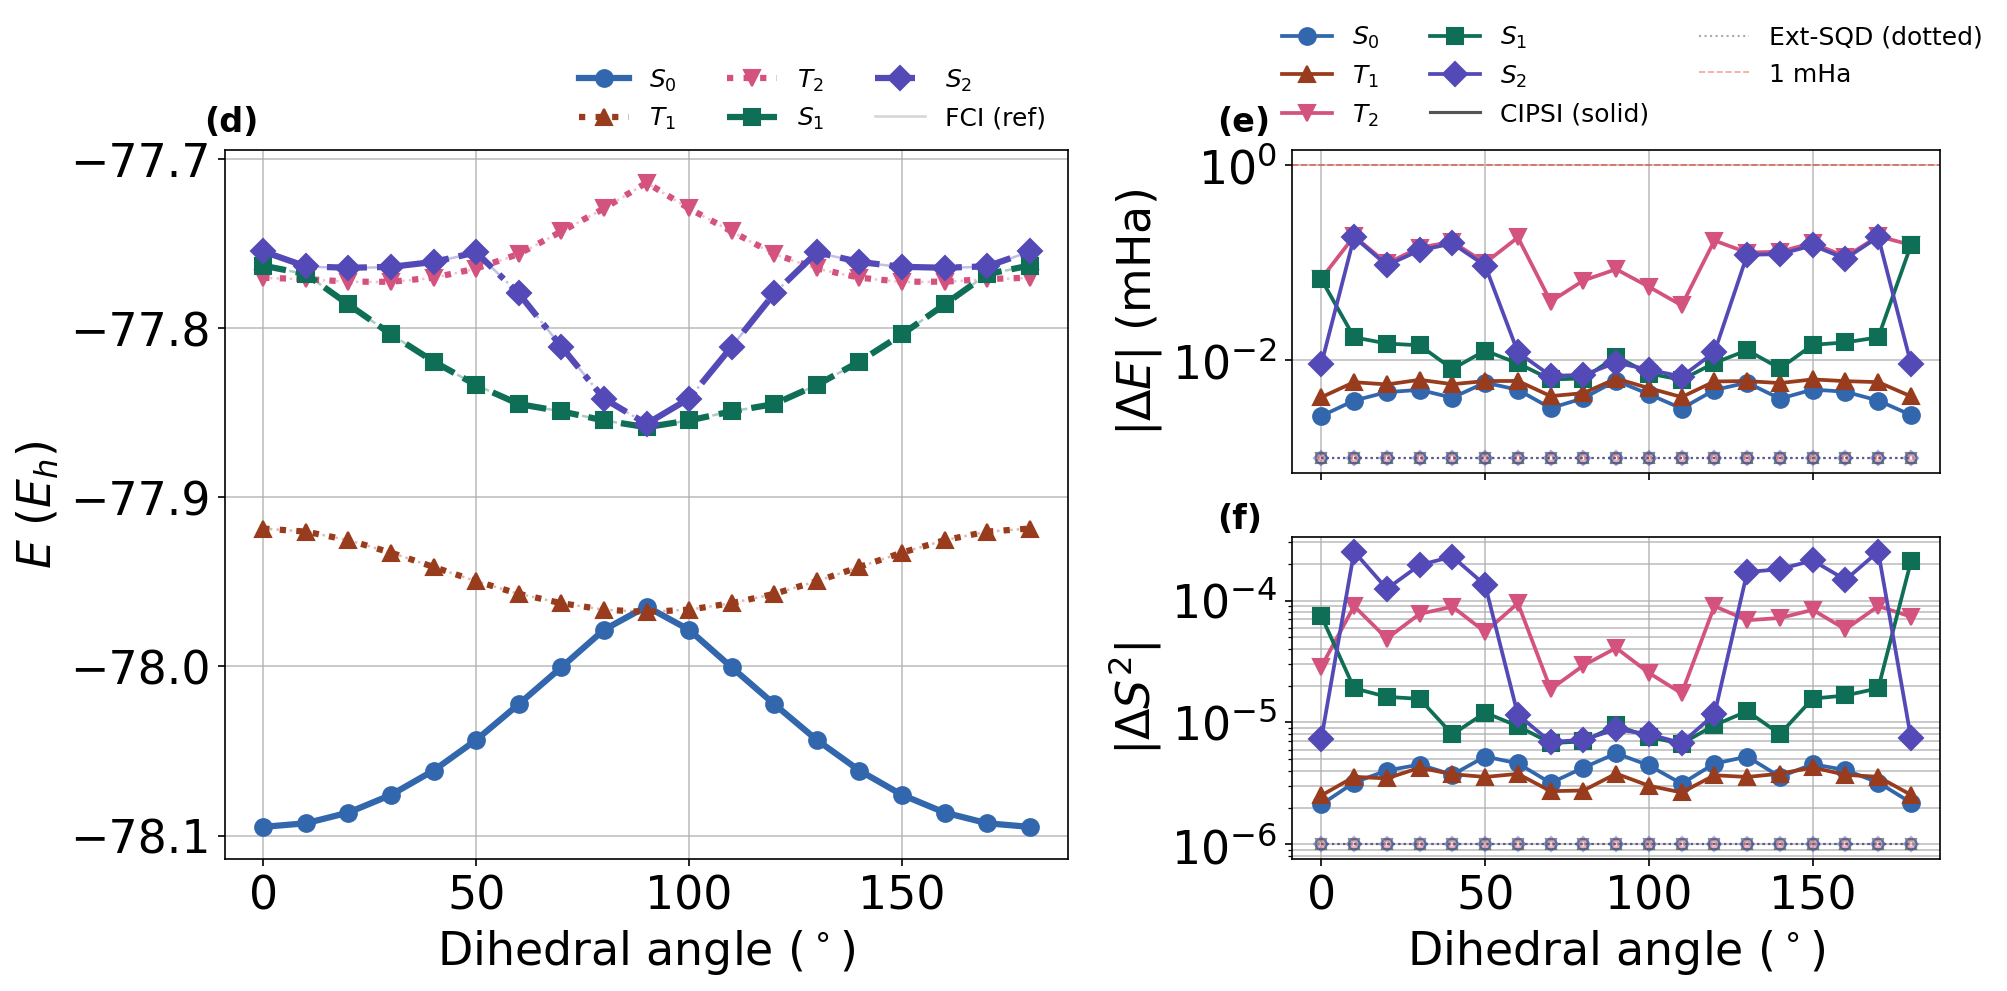

[saved] c2h4_14o_fig1_cipsi.png  (35.0×16.0 cm, 600 DPI)


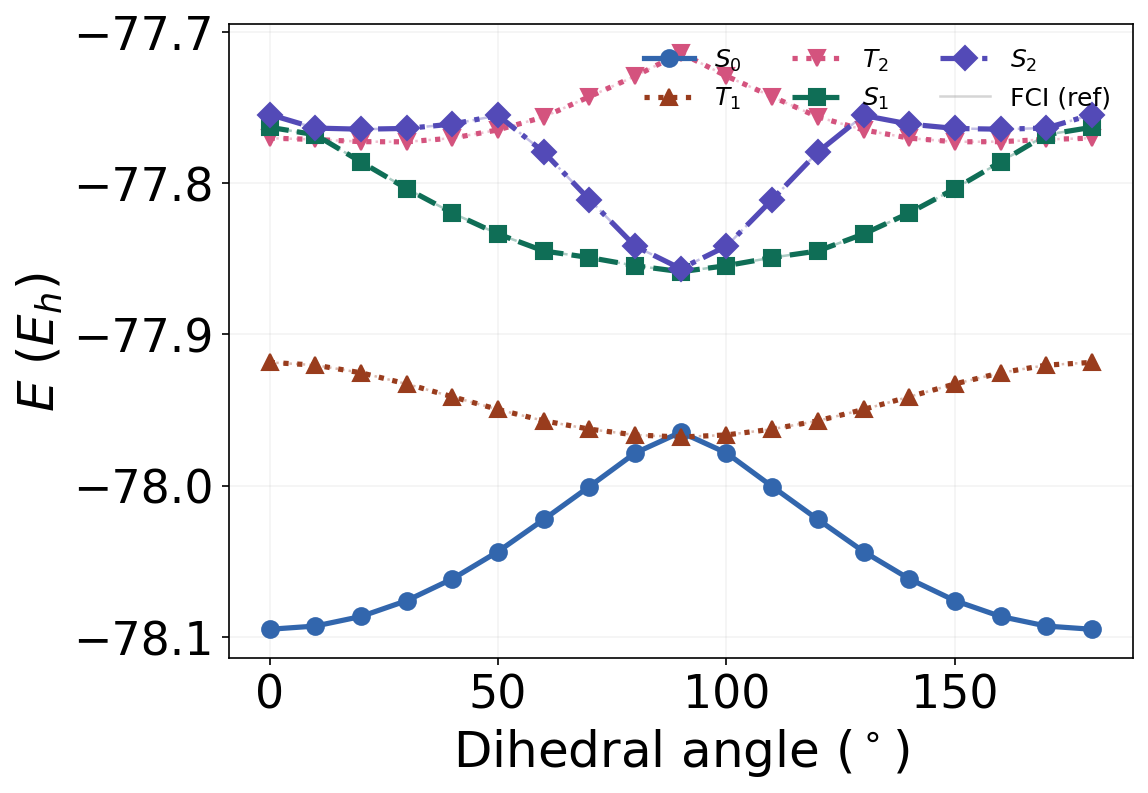

[saved] c2h4_14o_fig2_ext.png  (20.0×14.0 cm, 600 DPI)


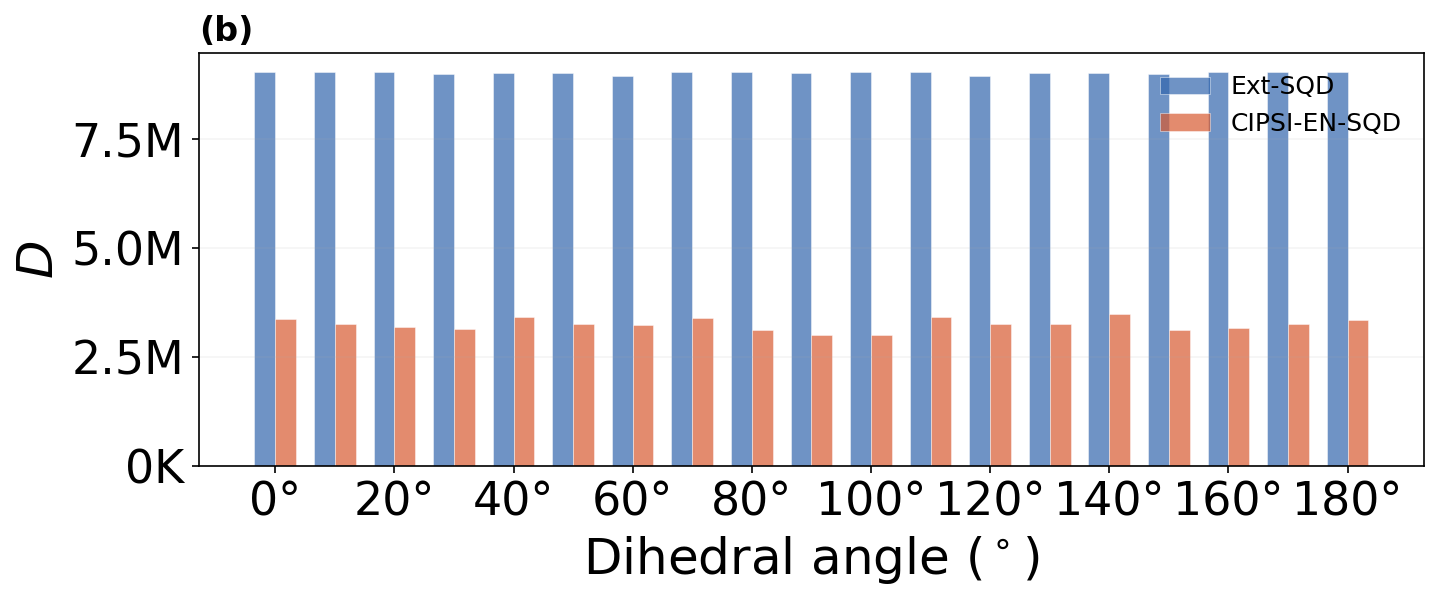

[saved] c2h4_14o_fig3_subspace.png  (25.0×10.0 cm, 600 DPI)


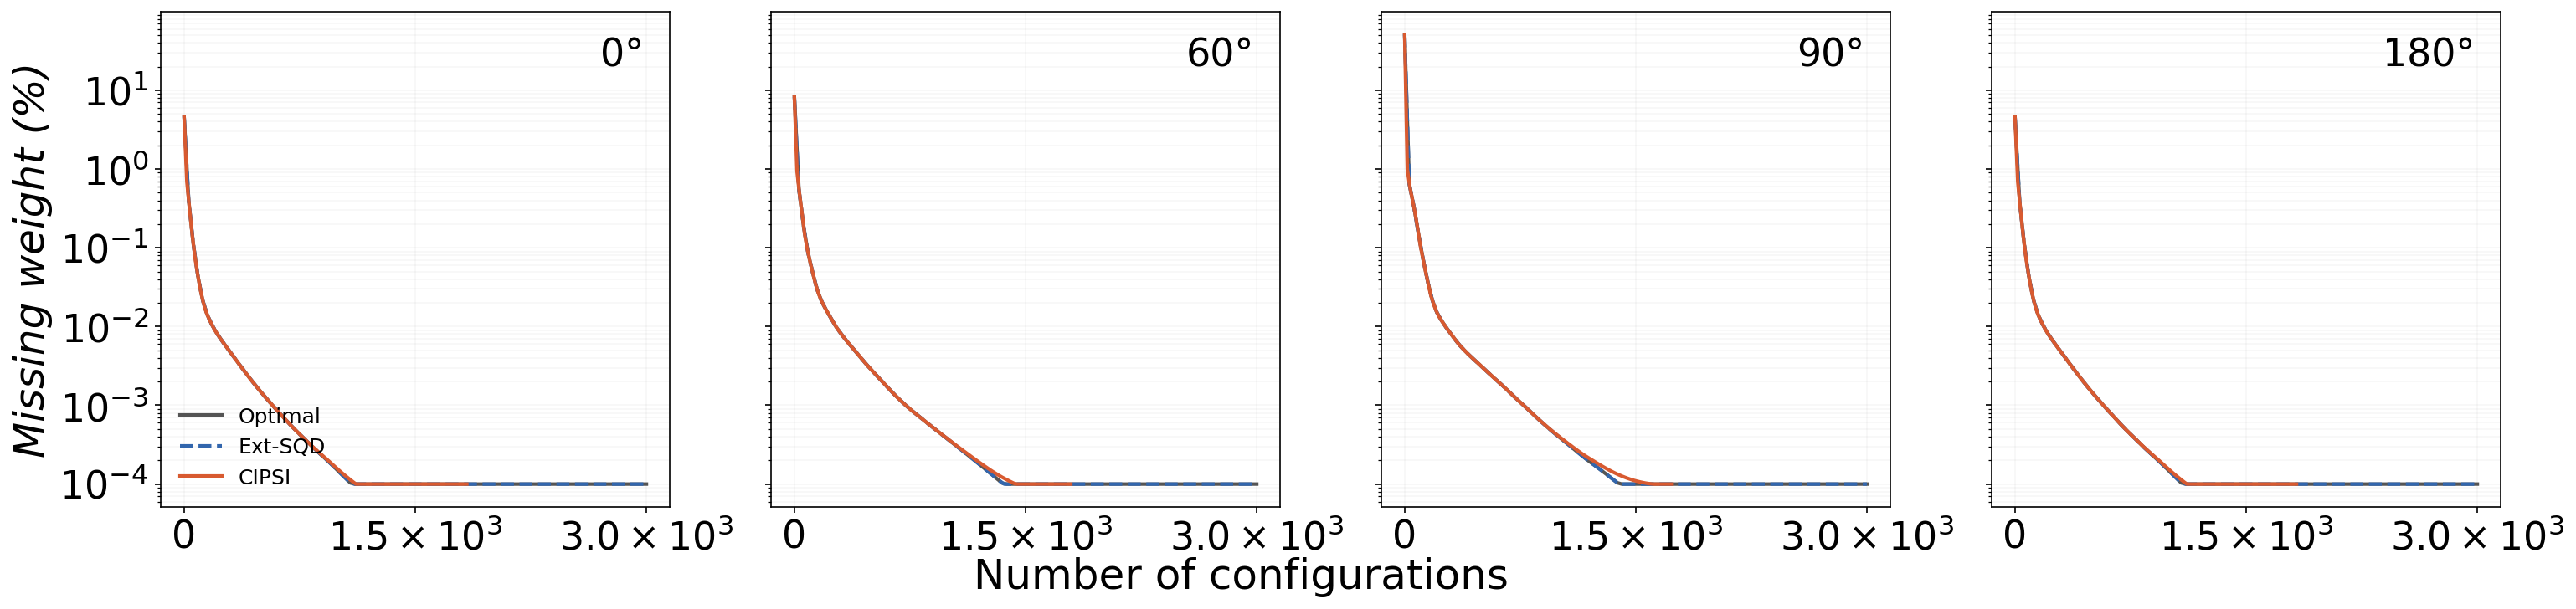

[saved] c2h4_14o_fig4_cumulative.png  (52.0×13.0 cm, 600 DPI)


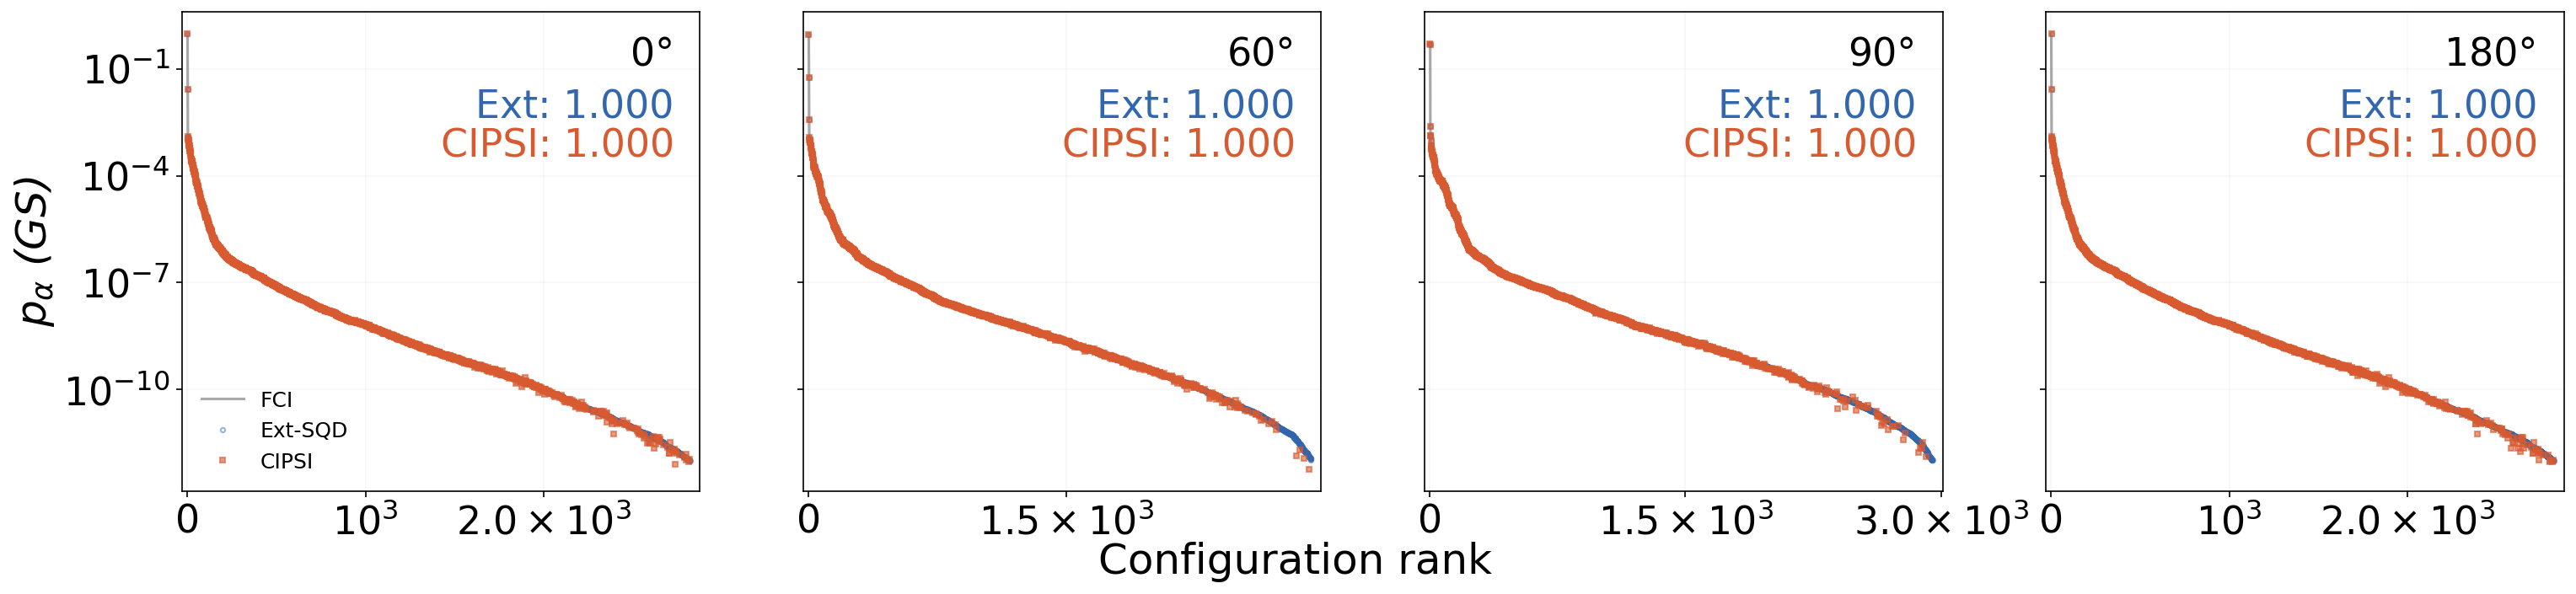

[saved] c2h4_14o_fig5_amplitude.png  (52.0×13.0 cm, 600 DPI)


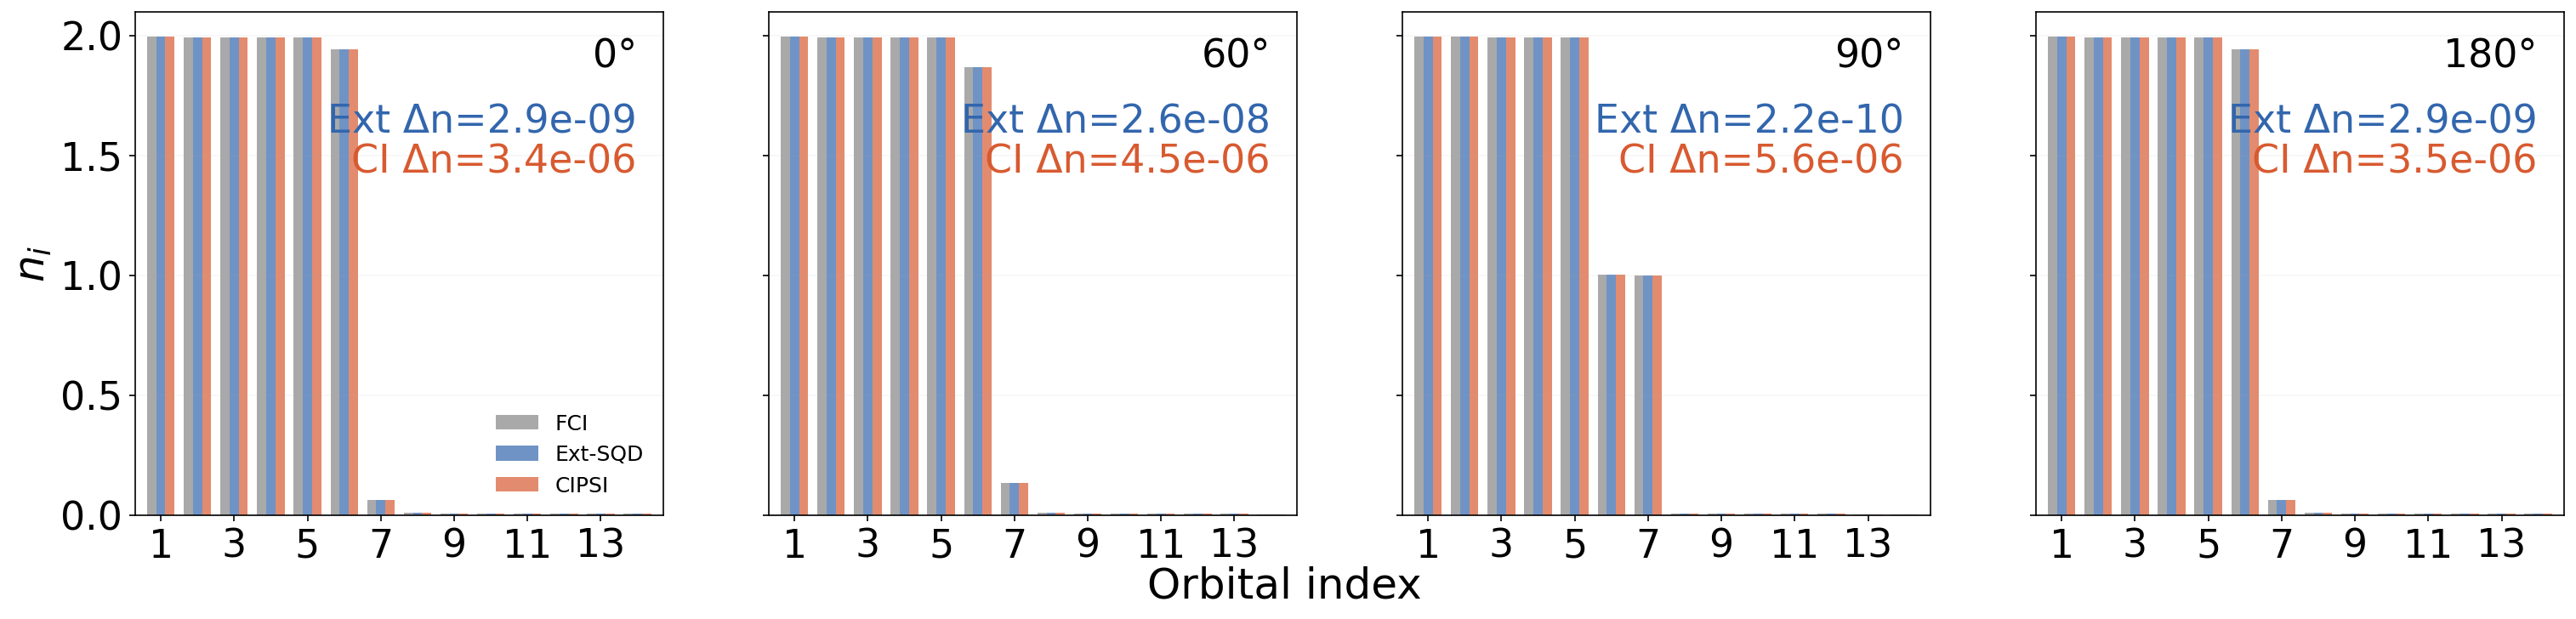

[saved] c2h4_14o_fig6_natorb.png  (52.0×13.0 cm, 600 DPI)

 Angle |    ext  cipsi     % |    S0_ext    S0_ci |   T1_ext    T1_ci |   T2_ext    T2_ci |   S1_ext    S1_ci |   S2_ext    S2_ci |
------------------------------------------------------------------------------------------------------------------------
    0° | 9018009 3374569   37% |     +0.00    +0.00 |    +0.00    +0.00 |    -0.00    +0.07 |    -0.00    +0.07 |    -0.00    +0.01 |
   10° | 9018009 3243601   36% |     +0.00    +0.00 |    +0.00    +0.01 |    +0.00    +0.19 |    -0.00    +0.02 |    +0.00    +0.18 |
   20° | 9018009 3189796   35% |     +0.00    +0.00 |    +0.00    +0.01 |    -0.00    +0.10 |    +0.00    +0.01 |    -0.00    +0.09 |
   30° | 8976016 3150625   35% |     +0.00    +0.00 |    +0.00    +0.01 |    +0.00    +0.14 |    +0.00    +0.01 |    +0.00    +0.13 |
   40° | 9012004 3426201   38% |     +0.00    +0.00 |    +0.00    +0.01 |    +0.00    +0.16 |    +0.00    +0.01 |    +0.00    +0.16 |
   50° | 8994001 3

In [11]:
#!/usr/bin/env python
"""C2H4 (12e,14o) twist scan figures — closed-shell.

x-axis: dihedral angle (0°–180°)
States: S0, T1, T2, S1, S2

Fig 1: CIPSI-EN-SQD  [PES | ΔE / ΔS²]
Fig 2: Ext-SQD PES (SI)
Fig 3: Subspace dimension
Fig 4: Cumulative WF recovery
Fig 5: GS amplitude (OLD format)
Fig 6: Natural orbital occupation
"""
import json, numpy as np, matplotlib, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
try: get_ipython()
except: matplotlib.use("Agg")

# ============ Config ============
FNAME = "c2h4_14o_twist.json"
PREFIX = "c2h4_14o"
SAVE_DPI = 600
EXACT_SIZE = True

def cm2in(w, h): return (w / 2.54, h / 2.54)

# ============ Fig 1 설정 ============
FIG1_SIZE  = (35, 16)
FIG1_FONT  = 22
FIG1_TICK  = 22
FIG1_LGD   = 12
FIG1_MS    = 8
FIG1_MS2   = 5
FIG1_PANEL = 16
FIG1_PANEL_POS = {"(d)": (0.14, 0.92), "(e)": (0.63, 0.92), "(f)": (0.63, 0.50)}
FIG1_LAYOUT = dict(wratio=[1.3, 1], wspace=0.30, hspace=0.20,
                   left=0.15, right=0.98, top=0.90, bottom=0.15)

# ============ Fig 2-6 공통 ============
FIG2_SIZE  = (20, 14)
FIG3_SIZE  = (25, 10)
FIG_PNL    = (13, 13)
FONT       = 24
TICK       = 22
LGD        = 12
ANNOT      = 22
ANNOT_S    = 22
PANEL      = 16
MS         = 8
MS_SC      = 2.5

C_REF   = "#555555"
C_EXT   = "#3266ad"
C_CIPSI = "#D85A30"

STATES = ["S0", "T1", "T2", "S1", "S2"]
ST_DISP = {"S0": r"$S_0$", "T1": r"$T_1$", "T2": r"$T_2$", "S1": r"$S_1$", "S2": r"$S_2$"}
ST_COL  = {"S0": "#3266ad", "T1": "#993C1D", "T2": "#D4537E", "S1": "#0F6E56", "S2": "#534AB7"}
ST_MK   = {"S0": "o", "T1": "^", "T2": "v", "S1": "s", "S2": "D"}
ST_LS   = {"S0": "-", "T1": ":", "T2": ":", "S1": "--", "S2": "-."}
S2_EXACT = {"S0": 0.0, "T1": 2.0, "T2": 2.0, "S1": 0.0, "S2": 0.0}

REPR_ANGLES = [0, 60, 90, 180]  # representative dihedral angles

plt.rcParams.update({"font.size": 14, "figure.dpi": 150, "savefig.dpi": SAVE_DPI})

XLABEL = r"Dihedral angle ($^\circ$)"

def sci_fmt(x, pos):
    if x == 0: return "0"
    exp = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**exp
    if exp == 0: return f"{coeff:.0f}"
    if abs(coeff - 1.0) < 0.05: return rf"$10^{{{exp}}}$"
    return rf"${coeff:.1f}\times10^{{{exp}}}$"

# ============ Load ============
with open(FNAME) as f: all_data = json.load(f)
all_data.sort(key=lambda d: d["R"])
STATES = [s for s in STATES if any(pt.get("fci",{}).get(s) is not None for pt in all_data)]
angles = [pt["R"] for pt in all_data]  # R = dihedral angle in degrees
print(f"Loaded {FNAME}: {len(all_data)} pts, angles={angles[0]:.0f}°–{angles[-1]:.0f}°, states={STATES}")

def get_repr_idx():
    idx = []
    for a in REPR_ANGLES:
        dists = [abs(ang - a) for ang in angles]
        idx.append(dists.index(min(dists)))
    return sorted(set(idx))

def get_dim(dims, key):
    """Get total subspace dim (α×β)."""
    if key == "ext":
        for ka, kb in [("ext_a", "ext_b"), ("ext_alpha", "ext_beta")]:
            if ka in dims and kb in dims: return dims[ka] * dims[kb]
        if "ext" in dims: return dims["ext"]
    elif key == "cipsi":
        for ka, kb in [("cipsi_a", "cipsi_b"), ("cipsi_alpha", "cipsi_beta")]:
            if ka in dims and kb in dims: return dims[ka] * dims[kb]
        if "cipsi" in dims: return dims["cipsi"]
    return dims.get(key, 0)

def savefig(fig, name):
    if EXACT_SIZE: fig.savefig(f"{PREFIX}_{name}.png", dpi=SAVE_DPI)
    else: fig.savefig(f"{PREFIX}_{name}.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()
    w_in, h_in = fig.get_size_inches()
    print(f"[saved] {PREFIX}_{name}.png  ({w_in*2.54:.1f}×{h_in*2.54:.1f} cm, {SAVE_DPI} DPI)")


# ============================================================================
# Fig 1: CIPSI [PES | ΔE / ΔS²]
# ============================================================================
fig1 = plt.figure(figsize=cm2in(*FIG1_SIZE))
gs1 = fig1.add_gridspec(2, 2, width_ratios=FIG1_LAYOUT["wratio"], hspace=FIG1_LAYOUT["hspace"], wspace=FIG1_LAYOUT["wspace"])
ax1_pes = fig1.add_subplot(gs1[:, 0])
ax1_de  = fig1.add_subplot(gs1[0, 1])
ax1_ds2 = fig1.add_subplot(gs1[1, 1])

for lb in STATES:
    col, ls, mk = ST_COL[lb], ST_LS[lb], ST_MK[lb]
    a_ref = [pt["R"] for pt in all_data if pt["fci"].get(lb) is not None]
    e_ref = [pt["fci"][lb] for pt in all_data if pt["fci"].get(lb) is not None]
    a_ci  = [pt["R"] for pt in all_data if pt["cipsi"].get(lb) is not None]
    e_ci  = [pt["cipsi"][lb] for pt in all_data if pt["cipsi"].get(lb) is not None]
    ax1_pes.plot(a_ref, e_ref, color=col, ls=ls, lw=1.2, alpha=0.35)
    if e_ci:
        ax1_pes.plot(a_ci, e_ci, color=col, ls=ls, lw=3.0, marker=mk, ms=FIG1_MS, label=ST_DISP[lb])
ax1_pes.plot([], [], color="#888", ls="-", lw=1.2, alpha=0.35, label="FCI (ref)")
ax1_pes.set_xlabel(XLABEL, fontsize=FIG1_FONT)
ax1_pes.set_ylabel(r"$E$ ($E_h$)", fontsize=FIG1_FONT)
ax1_pes.legend(fontsize=FIG1_LGD, ncol=3, loc="upper right", frameon=False, bbox_to_anchor=(1, 1.15))
ax1_pes.tick_params(labelsize=FIG1_TICK); ax1_pes.grid(True, alpha=0.8)

for lb in STATES:
    col, mk = ST_COL[lb], ST_MK[lb]
    ext_a, ext_err = [], []
    for pt in all_data:
        ef = pt["fci"].get(lb); ee = pt["ext_sqd"].get(lb)
        if ef is not None and ee is not None:
            ext_a.append(pt["R"]); ext_err.append(max(abs(ee-ef)*1000, 1e-3))
    if ext_err:
        ax1_de.semilogy(ext_a, ext_err, color=col, ls=":", lw=1.0, marker=mk, ms=FIG1_MS2, fillstyle="none", alpha=0.5)
    ci_a, ci_err = [], []
    for pt in all_data:
        ef = pt["fci"].get(lb); ec = pt["cipsi"].get(lb)
        if ef is not None and ec is not None:
            ci_a.append(pt["R"]); ci_err.append(max(abs(ec-ef)*1000, 1e-3))
    if ci_err:
        ax1_de.semilogy(ci_a, ci_err, color=col, ls="-", lw=1.8, marker=mk, ms=FIG1_MS, label=ST_DISP[lb])
ax1_de.axhline(1.0, color="#e74c3c", ls="--", lw=0.8, alpha=0.5)
ax1_de.plot([], [], color="#555", ls="-", lw=1.5, label="CIPSI (solid)")
ax1_de.plot([], [], color="#555", ls=":", lw=1.0, alpha=0.5, label="Ext-SQD (dotted)")
ax1_de.axhline(1.0, color="#e74c3c", ls="--", lw=0.8, alpha=0.5, label="1 mHa")
ax1_de.set_ylabel(r"$|\Delta E|$ (mHa)", fontsize=FIG1_FONT)
ax1_de.legend(fontsize=FIG1_LGD, ncol=3, loc="lower left", frameon=False, bbox_to_anchor=(-0.05, 1.0))
ax1_de.tick_params(labelsize=FIG1_TICK, labelbottom=False)
ax1_de.grid(True, which="both", alpha=0.8)

for lb in STATES:
    col, mk = ST_COL[lb], ST_MK[lb]
    s2_exact = S2_EXACT[lb]
    ext_a, ext_ds2, ci_a, ci_ds2 = [], [], [], []
    for pt in all_data:
        s2e = pt.get("ext_s2", {}).get(lb)
        if s2e is not None: ext_a.append(pt["R"]); ext_ds2.append(max(abs(s2e-s2_exact), 1e-6))
        s2c = pt.get("cipsi_s2", {}).get(lb)
        if s2c is not None: ci_a.append(pt["R"]); ci_ds2.append(max(abs(s2c-s2_exact), 1e-6))
    if ext_ds2:
        ax1_ds2.semilogy(ext_a, ext_ds2, color=col, ls=":", lw=1.0, marker=mk, ms=FIG1_MS2, fillstyle="none", alpha=0.45)
    if ci_ds2:
        ax1_ds2.semilogy(ci_a, ci_ds2, color=col, ls="-", lw=1.8, marker=mk, ms=FIG1_MS, label=ST_DISP[lb])
ax1_ds2.plot([], [], color="#555", ls="-", lw=1.5, label="CIPSI (solid)")
ax1_ds2.plot([], [], color="#555", ls=":", lw=1.0, alpha=0.5, label="Ext-SQD (dotted)")
ax1_ds2.set_xlabel(XLABEL, fontsize=FIG1_FONT)
ax1_ds2.set_ylabel(r"$|\Delta S^2|$", fontsize=FIG1_FONT)
# ax1_ds2.legend(fontsize=FIG1_LGD-2, ncol=2, loc="upper left", frameon=False)
ax1_ds2.tick_params(labelsize=FIG1_TICK); ax1_ds2.grid(True, which="both", alpha=0.8)

for lbl, (fx, fy) in FIG1_PANEL_POS.items():
    fig1.text(fx, fy, lbl, fontsize=FIG1_PANEL, fontweight="bold")
fig1.subplots_adjust(**{k: v for k, v in FIG1_LAYOUT.items() if k not in ("wratio", "wspace", "hspace")})
savefig(fig1, "fig1_cipsi")


# ============================================================================
# Fig 2: Ext-SQD PES (SI)
# ============================================================================
fig2, ax2 = plt.subplots(figsize=cm2in(*FIG2_SIZE))
for lb in STATES:
    col, ls, mk = ST_COL[lb], ST_LS[lb], ST_MK[lb]
    a_ref = [pt["R"] for pt in all_data if pt["fci"].get(lb) is not None]
    e_ref = [pt["fci"][lb] for pt in all_data if pt["fci"].get(lb) is not None]
    a_ext = [pt["R"] for pt in all_data if pt["ext_sqd"].get(lb) is not None]
    e_ext = [pt["ext_sqd"][lb] for pt in all_data if pt["ext_sqd"].get(lb) is not None]
    ax2.plot(a_ref, e_ref, color=col, ls=ls, lw=1.2, alpha=0.35)
    if e_ext: ax2.plot(a_ext, e_ext, color=col, ls=ls, lw=2.5, marker=mk, ms=MS, label=ST_DISP[lb])
ax2.plot([], [], color="#888", ls="-", lw=1.2, alpha=0.35, label="FCI (ref)")
ax2.set_xlabel(XLABEL, fontsize=FONT); ax2.set_ylabel(r"$E$ ($E_h$)", fontsize=FONT)
ax2.legend(fontsize=LGD, ncol=3, loc="upper right", frameon=False)
ax2.tick_params(labelsize=TICK); ax2.grid(True, alpha=0.15); fig2.tight_layout()
savefig(fig2, "fig2_ext")


# ============================================================================
# Fig 3: Subspace dimension (C2H4 uses ext_alpha/cipsi_alpha)
# ============================================================================
fig3, ax3 = plt.subplots(figsize=cm2in(*FIG3_SIZE))
ext_ds = [get_dim(pt["dims"], "ext") for pt in all_data]
ci_ds  = [get_dim(pt["dims"], "cipsi") for pt in all_data]
x = np.arange(len(angles)); bar_w = 0.35
ax3.bar(x-bar_w/2, ext_ds, bar_w, color=C_EXT, alpha=0.7, label="Ext-SQD", edgecolor="white", lw=0.3)
ax3.bar(x+bar_w/2, ci_ds, bar_w, color=C_CIPSI, alpha=0.7, label="CIPSI-EN-SQD", edgecolor="white", lw=0.3)
tick_step = max(2, len(angles)//8)
ax3.set_xticks(x[::tick_step])
ax3.set_xticklabels([f"{angles[i]:.0f}°" for i in range(0, len(angles), tick_step)], fontsize=TICK)
ax3.set_xlabel(XLABEL, fontsize=FONT)
ax3.set_ylabel(r"$D$", fontsize=FONT, fontstyle="italic")
ax3.legend(fontsize=LGD, frameon=False)
ax3.tick_params(labelsize=TICK); ax3.grid(True, alpha=0.12, axis="y")
ax3.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
fig3.subplots_adjust(left=0.15, right=0.98, top=0.90, bottom=0.2)
fig3.text(0.15, 0.92, "(b)", fontsize=PANEL, fontweight="bold")
savefig(fig3, "fig3_subspace")


# ============================================================================
# Fig 4: Cumulative WF recovery
# ============================================================================
has_curves = any(pt.get("wf_analysis", {}).get("opt_curve", {}).get("x") for pt in all_data)
if has_curves:
    repr_idx = get_repr_idx()
    n_panels = len(repr_idx)
    fig4, axes4 = plt.subplots(1, n_panels, figsize=cm2in(FIG_PNL[0]*n_panels, FIG_PNL[1]),
                               sharey=True, squeeze=False)
    axes4 = axes4[0]
    for i, idx in enumerate(repr_idx):
        ax = axes4[i]; pt = all_data[idx]; wfa = pt.get("wf_analysis", {})
        for key, col, ls, lbl in [("opt_curve", C_REF, "-", "Optimal"),
                                    ("ext_curve", C_EXT, "--", "Ext-SQD"),
                                    ("cipsi_curve", C_CIPSI, "-", "CIPSI")]:
            curve = wfa.get(key, {})
            cx, cy = curve.get("x", []), curve.get("y", [])
            if cx:
                miss = [max(100-y, 1e-4) for y in cy]
                ax.semilogy(cx, miss, color=col, ls=ls, lw=2, label=lbl)
        ax.grid(True, which="both", alpha=0.1); ax.tick_params(labelsize=TICK)
        ax.xaxis.set_major_formatter(FuncFormatter(sci_fmt))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.text(0.95, 0.95, f"{pt['R']:.0f}°", transform=ax.transAxes, fontsize=ANNOT, ha="right", va="top")
    axes4[0].set_ylabel("Missing weight (%)", fontsize=FONT, fontstyle="italic")
    axes4[0].legend(loc="lower left", fontsize=LGD, frameon=False)
    fig4.supxlabel("Number of configurations", fontsize=FONT, y=0.02)
    fig4.subplots_adjust(left=0.08, right=0.99, top=0.93, bottom=0.16)
    savefig(fig4, "fig4_cumulative")
else:
    print("[skip] fig4_cumulative")


# ============================================================================
# Fig 5: GS amplitude (OLD format)
# ============================================================================
has_amps = any(pt.get("wf_amps", {}).get("ref") for pt in all_data)
if has_amps:
    repr_idx = get_repr_idx()
    n_panels = len(repr_idx)
    fig5, axes5 = plt.subplots(1, n_panels, figsize=cm2in(FIG_PNL[0]*n_panels, FIG_PNL[1]),
                               sharey=True, squeeze=False)
    axes5 = axes5[0]
    for i, idx in enumerate(repr_idx):
        ax = axes5[i]; pt = all_data[idx]
        amp = pt.get("wf_amps", {})
        ref_a = np.array(amp.get("ref", []))
        ext_a = np.array(amp.get("ext", []))
        ci_a  = np.array(amp.get("cipsi", []))
        if len(ref_a) == 0: continue
        x_rank = np.arange(1, len(ref_a)+1)
        mask = ref_a > 1e-12
        x_plot, ref_plot = x_rank[mask], ref_a[mask]
        ext_plot, ci_plot = ext_a[mask], ci_a[mask]
        ax.semilogy(x_plot, ref_plot, color=C_REF, lw=1.5, alpha=0.5, label="FCI")
        me = ext_plot > 1e-14
        if me.any(): ax.semilogy(x_plot[me], ext_plot[me], color=C_EXT, lw=0, marker="o", ms=MS_SC, fillstyle="none", alpha=0.5, label="Ext-SQD")
        mc = ci_plot > 1e-14
        if mc.any(): ax.semilogy(x_plot[mc], ci_plot[mc], color=C_CIPSI, lw=0, marker="s", ms=MS_SC, alpha=0.6, label="CIPSI")
        ov_ext = np.sum(np.minimum(ref_a, ext_a))
        ov_ci  = np.sum(np.minimum(ref_a, ci_a))
        ax.text(0.95, 0.84, f"Ext: {ov_ext:.3f}", transform=ax.transAxes, fontsize=ANNOT_S, ha="right", va="top", color=C_EXT)
        ax.text(0.95, 0.76, f"CIPSI: {ov_ci:.3f}", transform=ax.transAxes, fontsize=ANNOT_S, ha="right", va="top", color=C_CIPSI)
        ax.set_xlim(-max(x_plot)*0.01, max(x_plot)*1.02)
        ax.grid(True, alpha=0.1); ax.tick_params(labelsize=TICK)
        ax.xaxis.set_major_formatter(FuncFormatter(sci_fmt)); ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.text(0.95, 0.95, f"{pt['R']:.0f}°", transform=ax.transAxes, fontsize=ANNOT, ha="right", va="top")
    axes5[0].set_ylabel(r"$p_\alpha$ (GS)", fontsize=FONT, fontstyle="italic")
    axes5[0].legend(loc="lower left", fontsize=LGD, frameon=False)
    fig5.supxlabel("Configuration rank", fontsize=FONT, y=0.02)
    fig5.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.16)
    savefig(fig5, "fig5_amplitude")
else:
    print("[skip] fig5_amplitude")


# ============================================================================
# Fig 6: Natural orbital occupation
# ============================================================================
has_no = any(pt.get("nat_occ", {}).get("ref") for pt in all_data)
if has_no:
    repr_idx = get_repr_idx()
    n_panels = len(repr_idx)
    fig6, axes6 = plt.subplots(1, n_panels, figsize=cm2in(FIG_PNL[0]*n_panels, FIG_PNL[1]),
                               sharey=True, squeeze=False)
    axes6 = axes6[0]
    for i, idx in enumerate(repr_idx):
        ax = axes6[i]; pt = all_data[idx]; no = pt.get("nat_occ", {})
        ref_n = np.array(no.get("ref", [])); ext_n = np.array(no.get("ext", [])); ci_n = np.array(no.get("cipsi", []))
        if len(ref_n) == 0: continue
        norb = len(ref_n); x = np.arange(1, norb+1); w = 0.25
        ax.bar(x-w, ref_n, w, color=C_REF, alpha=0.5, label="FCI")
        if len(ext_n) == norb: ax.bar(x, ext_n, w, color=C_EXT, alpha=0.7, label="Ext-SQD")
        if len(ci_n) == norb:  ax.bar(x+w, ci_n, w, color=C_CIPSI, alpha=0.7, label="CIPSI")
        if len(ext_n) == norb:
            ax.text(0.95, 0.82, f"Ext Δn={np.max(np.abs(ref_n-ext_n)):.1e}", transform=ax.transAxes, fontsize=ANNOT_S, ha="right", va="top", color=C_EXT)
        if len(ci_n) == norb:
            ax.text(0.95, 0.74, f"CI Δn={np.max(np.abs(ref_n-ci_n)):.1e}", transform=ax.transAxes, fontsize=ANNOT_S, ha="right", va="top", color=C_CIPSI)
        ax.set_xticks(x[::2]); ax.set_xlim(0.3, norb+0.7)
        ax.tick_params(labelsize=TICK); ax.grid(True, alpha=0.1, axis="y")
        ax.text(0.95, 0.95, f"{pt['R']:.0f}°", transform=ax.transAxes, fontsize=ANNOT, ha="right", va="top")
    axes6[0].set_ylabel(r"$n_i$", fontsize=FONT, fontstyle="italic")
    axes6[0].legend(loc="lower right", fontsize=LGD, frameon=False)
    fig6.supxlabel("Orbital index", fontsize=FONT, y=0.02)
    fig6.subplots_adjust(left=0.06, right=0.99, top=0.93, bottom=0.16)
    savefig(fig6, "fig6_natorb")
else:
    print("[skip] fig6_natorb")


# ============================================================================
# Summary table
# ============================================================================
print(f"\n{'='*120}")
print(f"{'Angle':>6} | {'ext':>6} {'cipsi':>6} {'%':>5} | ", end="")
for lb in STATES: print(f" {lb+'_ext':>8} {lb+'_ci':>8} |", end="")
print()
print("-" * 120)
for pt in all_data:
    d = pt["dims"]
    ext_d = get_dim(d, "ext"); ci_d = get_dim(d, "cipsi")
    pct = ci_d/max(ext_d,1)*100
    row = f"{pt['R']:5.0f}° | {ext_d:>6} {ci_d:>6} {pct:>4.0f}% | "
    for lb in STATES:
        ef = pt["fci"].get(lb); ee = pt["ext_sqd"].get(lb); ec = pt["cipsi"].get(lb)
        de_ext = f"{(ee-ef)*1000:+.2f}" if ef and ee else "  -- "
        de_ci  = f"{(ec-ef)*1000:+.2f}" if ef and ec else "  -- "
        row += f" {de_ext:>8} {de_ci:>8} |"
    print(row)
print(f"\nDone. {len(all_data)} points.")